<a href="https://colab.research.google.com/github/hvchem/QRproject-/blob/main/Copy_of_itffc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install -q kaggle datasets huggingface_hub

In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"hvchem","key":"b104aa49173a4fd6efac469afb60284f"}'}

In [ ]:
!mkdir -p ~/.kaggle
!echo '{"username":"hvchem","key":"b104aa49173a4fd6efac469afb60284f"}' > ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset


Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): CC0-1.0
 85% 126M/149M [00:00<00:00, 1.32GB/s]
100% 149M/149M [00:00<00:00, 1.14GB/s]


In [ ]:
!unzip -q brain-tumor-mri-dataset.zip -d /content/brain-tumor-mri-dataset


In [ ]:
!ls /content/brain-tumor-mri-dataset


Testing  Training


In [ ]:
from datasets import load_dataset

dataset = load_dataset("imagefolder", data_dir="/content/brain-tumor-mri-dataset/Training")
dataset


Resolving data files:   0%|          | 0/5712 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 5712
    })
})

In [ ]:
!kaggle datasets download -d siddharthkumarsah/logo-dataset-2341-classes-and-167140-images -p /content/

# 5) Unzip the dataset
!unzip -q /content/logo-dataset-2341-classes-and-167140-images.zip -d /content/logo2k_plus

# 6) Verify folder contents
!ls /content/logo2k_plus

Dataset URL: https://www.kaggle.com/datasets/siddharthkumarsah/logo-dataset-2341-classes-and-167140-images
License(s): copyright-authors
100% 1.91G/1.91G [00:21<00:00, 272MB/s]
100% 1.91G/1.91G [00:21<00:00, 96.6MB/s]
datasetcopy


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from collections import Counter

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Define the dataset path
dataset_path = r'/content/brain-tumor-mri-dataset'
training_path = os.path.join(dataset_path, 'Training')
testing_path = os.path.join(dataset_path, 'Testing')

print("=" * 60)
print("BRAIN TUMOR CLASSIFICATION - DATASET OVERVIEW")
print("=" * 60)
print(f"\nDataset Location: {dataset_path}")
print(f"Training Data: {training_path}")
print(f"Testing Data: {testing_path}")


BRAIN TUMOR CLASSIFICATION - DATASET OVERVIEW

Dataset Location: /content/brain-tumor-mri-dataset
Training Data: /content/brain-tumor-mri-dataset/Training
Testing Data: /content/brain-tumor-mri-dataset/Testing



1. DATASET DISTRIBUTION ANALYSIS

Training Set:
  Glioma: 1321 images
  Meningioma: 1339 images
  Notumor: 1595 images
  Pituitary: 1457 images
  TOTAL: 5712 images

Testing Set:
  Glioma: 300 images
  Meningioma: 306 images
  Notumor: 405 images
  Pituitary: 300 images
  TOTAL: 1311 images


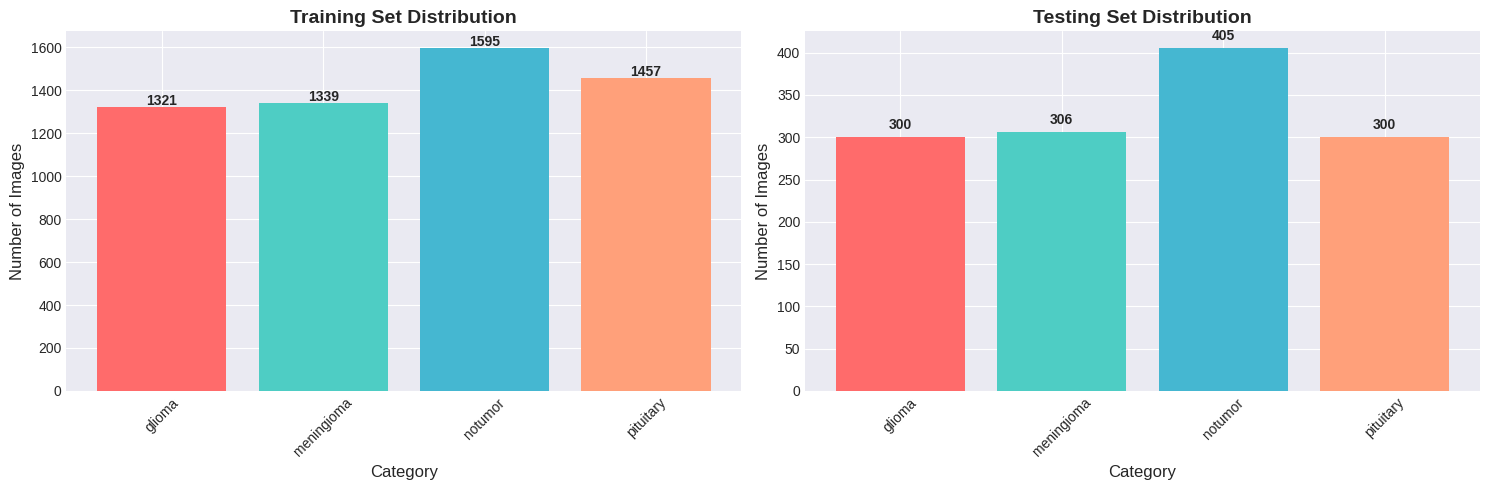


------------------------------------------------------------
Class Balance Analysis:
------------------------------------------------------------
Glioma          - Train: 23.13% | Test: 22.88%
Meningioma      - Train: 23.44% | Test: 23.34%
Notumor         - Train: 27.92% | Test: 30.89%
Pituitary       - Train: 25.51% | Test: 22.88%


In [ ]:
# EXPLORATORY DATA ANALYSIS - Part 1: Dataset Distribution
print("\n" + "=" * 60)
print("1. DATASET DISTRIBUTION ANALYSIS")
print("=" * 60)

# Categories in the dataset
categories = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Get statistics for all categories
train_stats = {}
test_stats = {}

for category in categories:
    train_category_path = os.path.join(training_path, category)
    test_category_path = os.path.join(testing_path, category)

    if os.path.exists(train_category_path):
        train_images = [f for f in os.listdir(train_category_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
        train_stats[category] = len(train_images)

    if os.path.exists(test_category_path):
        test_images = [f for f in os.listdir(test_category_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
        test_stats[category] = len(test_images)

# Print statistics
print("\nTraining Set:")
total_train = 0
for category, count in train_stats.items():
    print(f"  {category.capitalize()}: {count} images")
    total_train += count
print(f"  TOTAL: {total_train} images")

print("\nTesting Set:")
total_test = 0
for category, count in test_stats.items():
    print(f"  {category.capitalize()}: {count} images")
    total_test += count
print(f"  TOTAL: {total_test} images")

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Training set distribution
axes[0].bar(train_stats.keys(), train_stats.values(), color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
axes[0].set_title('Training Set Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category', fontsize=12)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
for i, (cat, val) in enumerate(train_stats.items()):
    axes[0].text(i, val + 10, str(val), ha='center', fontweight='bold')

# Testing set distribution
axes[1].bar(test_stats.keys(), test_stats.values(), color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
axes[1].set_title('Testing Set Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Category', fontsize=12)
axes[1].set_ylabel('Number of Images', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
for i, (cat, val) in enumerate(test_stats.items()):
    axes[1].text(i, val + 10, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Calculate class balance
print("\n" + "-" * 60)
print("Class Balance Analysis:")
print("-" * 60)
for category in categories:
    train_pct = (train_stats[category] / total_train) * 100
    test_pct = (test_stats[category] / total_test) * 100
    print(f"{category.capitalize():15} - Train: {train_pct:5.2f}% | Test: {test_pct:5.2f}%")


## Exploratory Data Analysis - Part 2: Sample Images

Let's visualize sample images from each category to understand the visual characteristics of different brain tumor types.


2. SAMPLE IMAGES FROM EACH CATEGORY


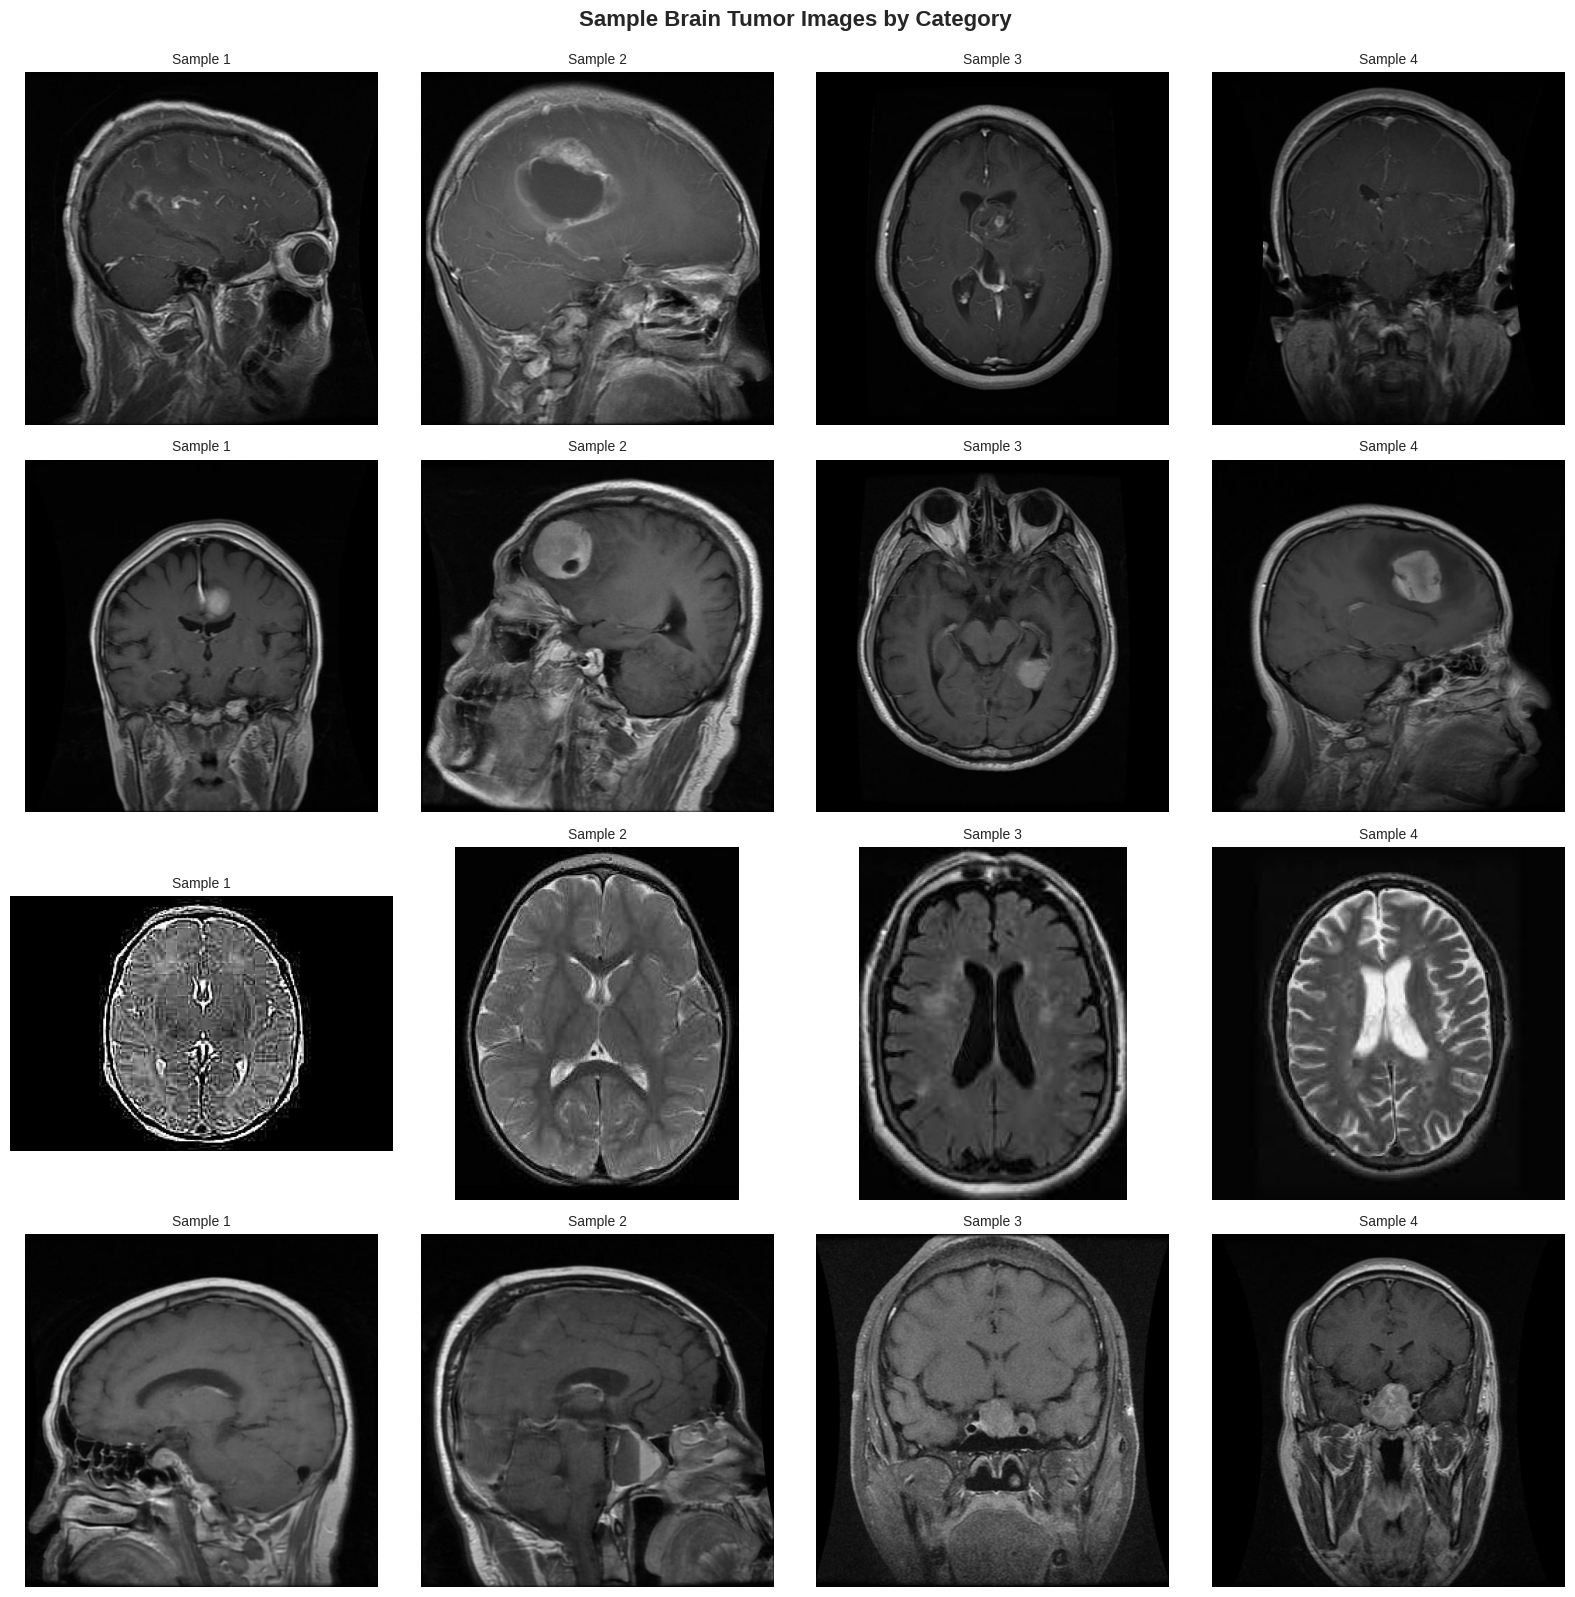


Image samples displayed successfully!


In [ ]:
# EDA - Part 2: Visualize Sample Images
print("\n" + "=" * 60)
print("2. SAMPLE IMAGES FROM EACH CATEGORY")
print("=" * 60)

# Display sample images from each category
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle('Sample Brain Tumor Images by Category', fontsize=16, fontweight='bold', y=0.995)

for i, category in enumerate(categories):
    category_path = os.path.join(training_path, category)
    image_files = [f for f in os.listdir(category_path) if f.endswith(('.jpg', '.png', '.jpeg'))]

    # Select 4 random samples
    samples = np.random.choice(image_files, min(4, len(image_files)), replace=False)

    for j, img_file in enumerate(samples):
        img_path = os.path.join(category_path, img_file)
        img = Image.open(img_path)

        axes[i, j].imshow(img, cmap='gray')
        if j == 0:
            axes[i, j].set_ylabel(category.capitalize(), fontsize=12, fontweight='bold')
        axes[i, j].set_title(f'Sample {j+1}', fontsize=10)
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

print("\nImage samples displayed successfully!")


## Exploratory Data Analysis - Part 3: Image Properties Analysis

Analyzing the dimensions, size, and color channels of the images.


3. IMAGE PROPERTIES ANALYSIS

Image Dimensions Summary:
------------------------------------------------------------

Glioma:
  Width:  512.0 ± 0.0 pixels
  Height: 512.0 ± 0.0 pixels
  Channels: 1.1 (Mode: 1)
  File Size: 18.4 ± 4.2 KB
  Aspect Ratio: 1.000

Meningioma:
  Width:  492.9 ± 70.8 pixels
  Height: 492.0 ± 68.8 pixels
  Channels: 2.5 (Mode: 3)
  File Size: 22.9 ± 5.4 KB
  Aspect Ratio: 1.001

Notumor:
  Width:  365.6 ± 208.5 pixels
  Height: 371.0 ± 194.5 pixels
  Channels: 2.9 (Mode: 3)
  File Size: 25.0 ± 25.9 KB
  Aspect Ratio: 0.981

Pituitary:
  Width:  506.9 ± 35.8 pixels
  Height: 506.9 ± 35.8 pixels
  Channels: 2.3 (Mode: 3)
  File Size: 29.0 ± 5.8 KB
  Aspect Ratio: 1.000


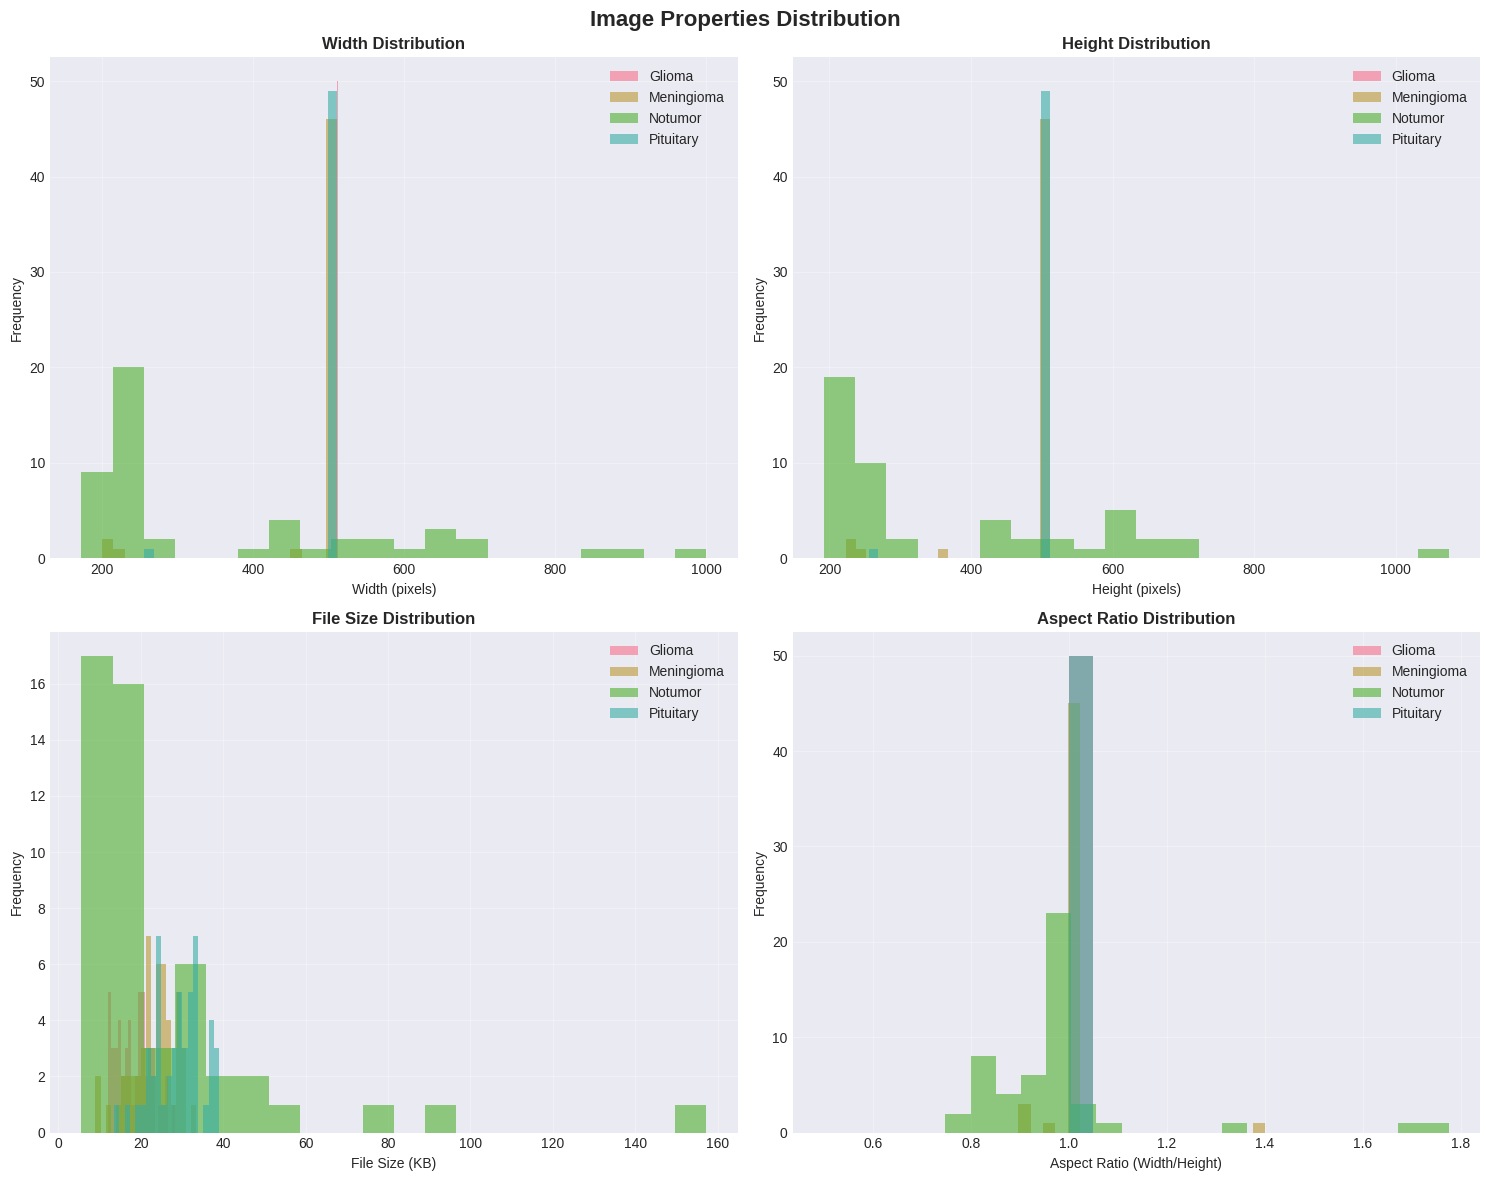

In [ ]:
# EDA - Part 3: Image Properties Analysis
print("\n" + "=" * 60)
print("3. IMAGE PROPERTIES ANALYSIS")
print("=" * 60)

# Function to get image properties
def get_image_properties(category_path, sample_size=50):
    properties = {
        'widths': [],
        'heights': [],
        'channels': [],
        'file_sizes': [],
        'aspects': []
    }

    image_files = [f for f in os.listdir(category_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
    samples = np.random.choice(image_files, min(sample_size, len(image_files)), replace=False)

    for img_file in samples:
        img_path = os.path.join(category_path, img_file)
        img = Image.open(img_path)

        properties['widths'].append(img.size[0])
        properties['heights'].append(img.size[1])
        properties['channels'].append(len(img.getbands()))
        properties['file_sizes'].append(os.path.getsize(img_path) / 1024)  # KB
        properties['aspects'].append(img.size[0] / img.size[1])

    return properties

# Collect properties for all categories
all_properties = {}
for category in categories:
    category_path = os.path.join(training_path, category)
    all_properties[category] = get_image_properties(category_path)

# Print summary statistics
print("\nImage Dimensions Summary:")
print("-" * 60)
for category in categories:
    props = all_properties[category]
    print(f"\n{category.capitalize()}:")
    print(f"  Width:  {np.mean(props['widths']):.1f} ± {np.std(props['widths']):.1f} pixels")
    print(f"  Height: {np.mean(props['heights']):.1f} ± {np.std(props['heights']):.1f} pixels")
    print(f"  Channels: {np.mean(props['channels']):.1f} (Mode: {Counter(props['channels']).most_common(1)[0][0]})")
    print(f"  File Size: {np.mean(props['file_sizes']):.1f} ± {np.std(props['file_sizes']):.1f} KB")
    print(f"  Aspect Ratio: {np.mean(props['aspects']):.3f}")

# Visualize dimensions
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Image Properties Distribution', fontsize=16, fontweight='bold')

# Width distribution
for category in categories:
    axes[0, 0].hist(all_properties[category]['widths'], alpha=0.6, label=category.capitalize(), bins=20)
axes[0, 0].set_title('Width Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Width (pixels)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Height distribution
for category in categories:
    axes[0, 1].hist(all_properties[category]['heights'], alpha=0.6, label=category.capitalize(), bins=20)
axes[0, 1].set_title('Height Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Height (pixels)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# File size distribution
for category in categories:
    axes[1, 0].hist(all_properties[category]['file_sizes'], alpha=0.6, label=category.capitalize(), bins=20)
axes[1, 0].set_title('File Size Distribution', fontweight='bold')
axes[1, 0].set_xlabel('File Size (KB)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Aspect ratio distribution
for category in categories:
    axes[1, 1].hist(all_properties[category]['aspects'], alpha=0.6, label=category.capitalize(), bins=20)
axes[1, 1].set_title('Aspect Ratio Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Aspect Ratio (Width/Height)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Exploratory Data Analysis - Part 4: Pixel Intensity Analysis

Analyzing pixel intensity distributions to understand the contrast and brightness characteristics.


4. PIXEL INTENSITY ANALYSIS

Pixel Intensity Statistics:
------------------------------------------------------------

Glioma:
  Mean Intensity:   32.19 ± 8.09
  Std Deviation:    39.42 ± 5.02
  Min Intensity:    0.00
  Max Intensity:    254.00
  Median Intensity: 13.17

Meningioma:
  Mean Intensity:   45.05 ± 14.51
  Std Deviation:    47.36 ± 12.34
  Min Intensity:    0.00
  Max Intensity:    253.97
  Median Intensity: 29.63

Notumor:
  Mean Intensity:   57.91 ± 20.26
  Std Deviation:    60.36 ± 18.27
  Min Intensity:    0.17
  Max Intensity:    247.70
  Median Intensity: 34.63

Pituitary:
  Mean Intensity:   50.93 ± 7.39
  Std Deviation:    41.59 ± 4.16
  Min Intensity:    0.00
  Max Intensity:    254.40
  Median Intensity: 50.37


/tmp/ipython-input-2635264615.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot([intensity_data[cat]['means'] for cat in categories],
/tmp/ipython-input-2635264615.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot([intensity_data[cat]['stds'] for cat in categories],
/tmp/ipython-input-2635264615.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot([intensity_data[cat]['mins'] for cat in categories],
/tmp/ipython-input-2635264615.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; sup

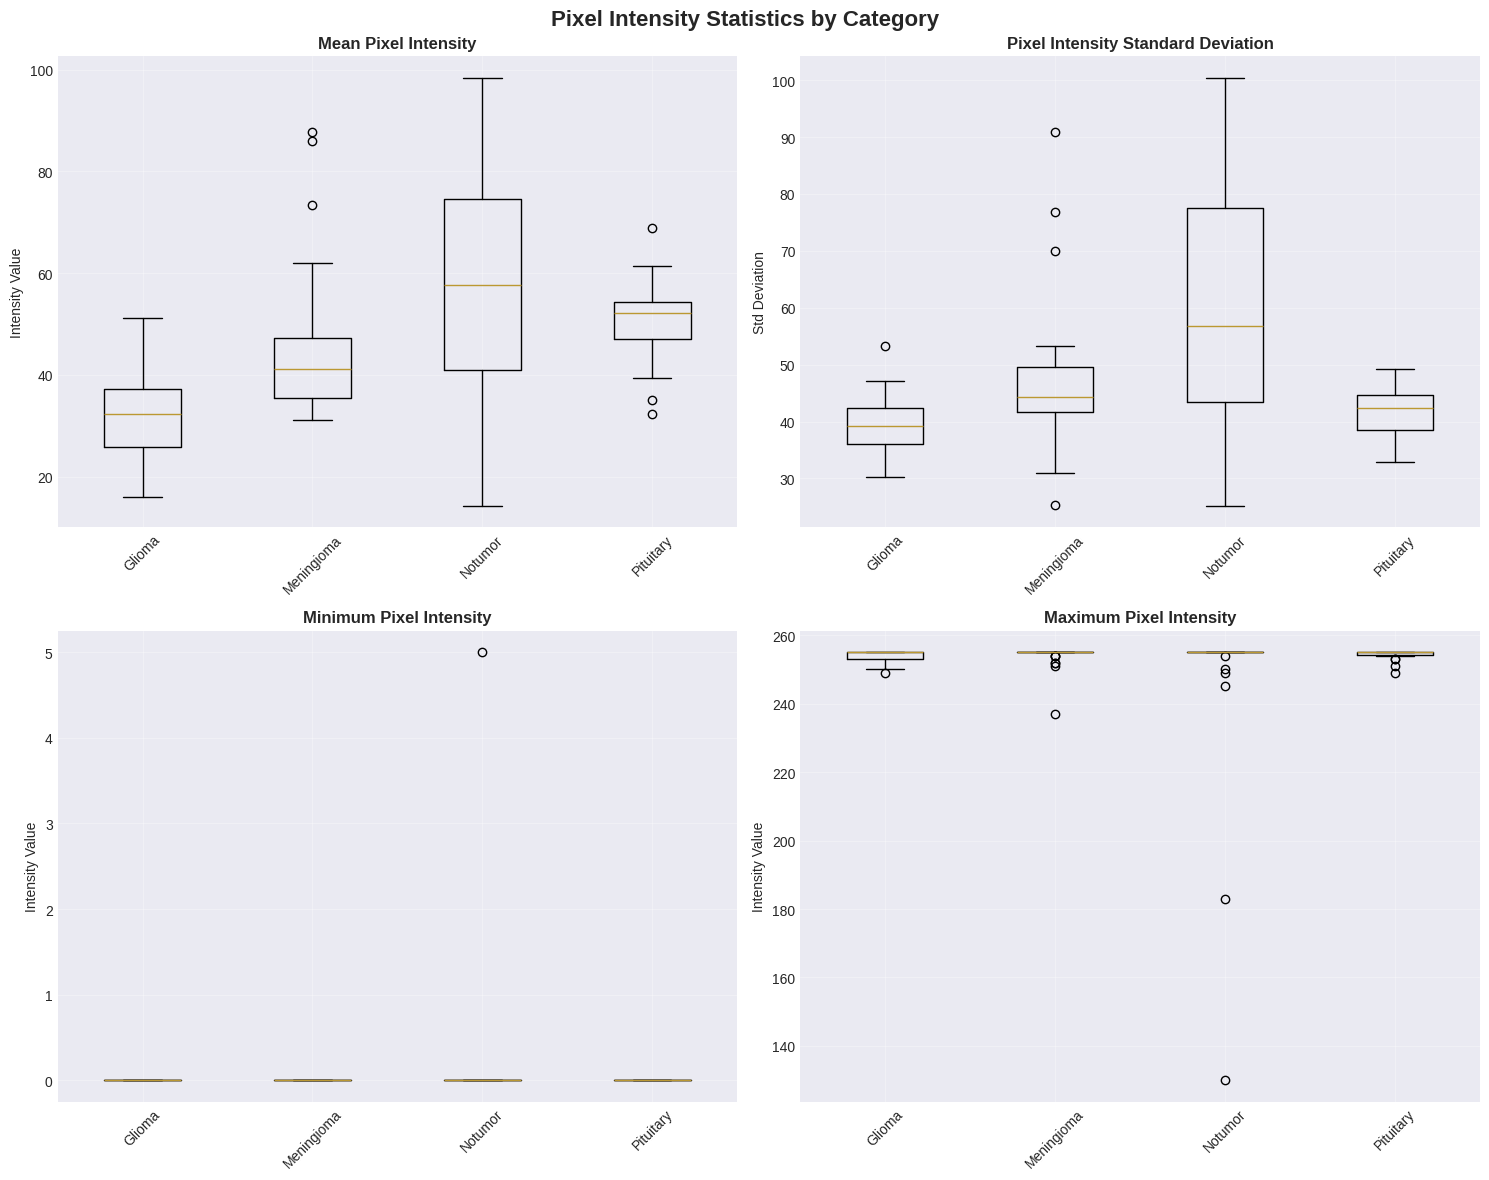

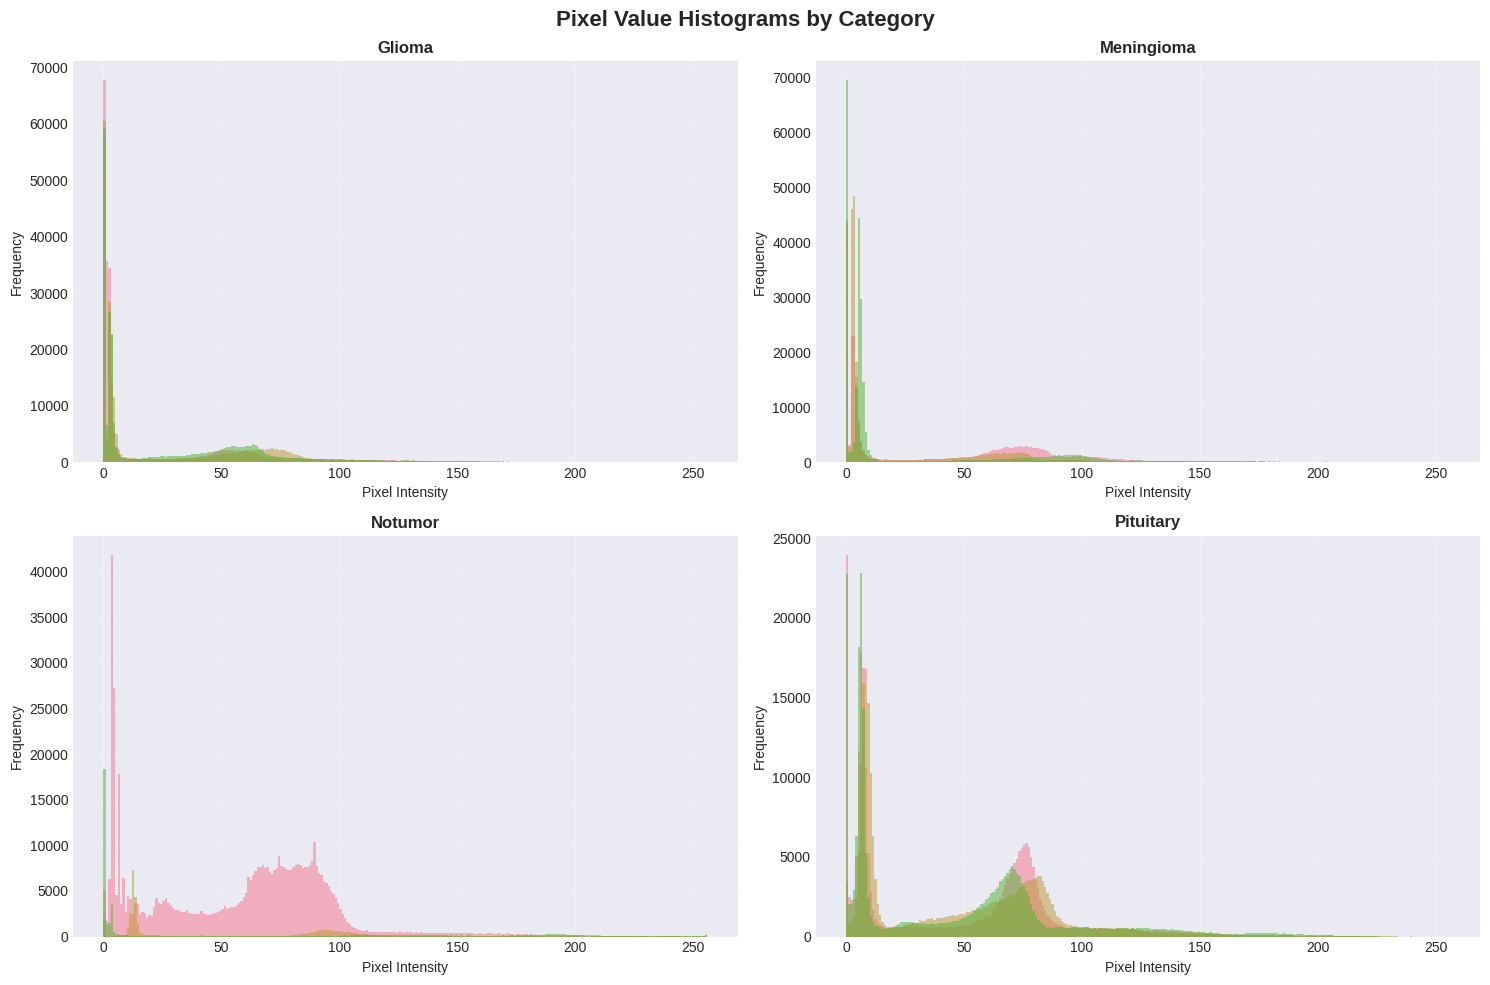

In [ ]:
# EDA - Part 4: Pixel Intensity Analysis
print("\n" + "=" * 60)
print("4. PIXEL INTENSITY ANALYSIS")
print("=" * 60)

# Function to analyze pixel intensities
def analyze_pixel_intensities(category_path, sample_size=30):
    intensities = {
        'means': [],
        'stds': [],
        'mins': [],
        'maxs': [],
        'medians': []
    }

    image_files = [f for f in os.listdir(category_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
    samples = np.random.choice(image_files, min(sample_size, len(image_files)), replace=False)

    for img_file in samples:
        img_path = os.path.join(category_path, img_file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is not None:
            intensities['means'].append(np.mean(img))
            intensities['stds'].append(np.std(img))
            intensities['mins'].append(np.min(img))
            intensities['maxs'].append(np.max(img))
            intensities['medians'].append(np.median(img))

    return intensities

# Collect intensity data
intensity_data = {}
for category in categories:
    category_path = os.path.join(training_path, category)
    intensity_data[category] = analyze_pixel_intensities(category_path)

# Print statistics
print("\nPixel Intensity Statistics:")
print("-" * 60)
for category in categories:
    data = intensity_data[category]
    print(f"\n{category.capitalize()}:")
    print(f"  Mean Intensity:   {np.mean(data['means']):.2f} ± {np.std(data['means']):.2f}")
    print(f"  Std Deviation:    {np.mean(data['stds']):.2f} ± {np.std(data['stds']):.2f}")
    print(f"  Min Intensity:    {np.mean(data['mins']):.2f}")
    print(f"  Max Intensity:    {np.mean(data['maxs']):.2f}")
    print(f"  Median Intensity: {np.mean(data['medians']):.2f}")

# Visualize intensity distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Pixel Intensity Statistics by Category', fontsize=16, fontweight='bold')

# Mean intensity
axes[0, 0].boxplot([intensity_data[cat]['means'] for cat in categories],
                    labels=[cat.capitalize() for cat in categories])
axes[0, 0].set_title('Mean Pixel Intensity', fontweight='bold')
axes[0, 0].set_ylabel('Intensity Value')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# Standard deviation
axes[0, 1].boxplot([intensity_data[cat]['stds'] for cat in categories],
                    labels=[cat.capitalize() for cat in categories])
axes[0, 1].set_title('Pixel Intensity Standard Deviation', fontweight='bold')
axes[0, 1].set_ylabel('Std Deviation')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3)

# Min intensity
axes[1, 0].boxplot([intensity_data[cat]['mins'] for cat in categories],
                    labels=[cat.capitalize() for cat in categories])
axes[1, 0].set_title('Minimum Pixel Intensity', fontweight='bold')
axes[1, 0].set_ylabel('Intensity Value')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3)

# Max intensity
axes[1, 1].boxplot([intensity_data[cat]['maxs'] for cat in categories],
                    labels=[cat.capitalize() for cat in categories])
axes[1, 1].set_title('Maximum Pixel Intensity', fontweight='bold')
axes[1, 1].set_ylabel('Intensity Value')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualize histogram of pixel distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Pixel Value Histograms by Category', fontsize=16, fontweight='bold')

for idx, category in enumerate(categories):
    row = idx // 2
    col = idx % 2

    category_path = os.path.join(training_path, category)
    image_files = [f for f in os.listdir(category_path) if f.endswith(('.jpg', '.png', '.jpeg'))]

    # Sample 3 images for histogram
    samples = np.random.choice(image_files, min(3, len(image_files)), replace=False)

    for img_file in samples:
        img_path = os.path.join(category_path, img_file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is not None:
            axes[row, col].hist(img.ravel(), bins=256, alpha=0.5, range=(0, 256))

    axes[row, col].set_title(f'{category.capitalize()}', fontweight='bold')
    axes[row, col].set_xlabel('Pixel Intensity')
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
# PREPROCESSING PIPELINE

Now let's preprocess the dataset with multiple techniques:
1. **Resizing** - Standardize image dimensions
2. **Grayscale Conversion** - Simplify to single channel
3. **Normalization** - Scale pixel values to [0, 1]
4. **Histogram Equalization** - Enhance contrast
5. **Noise Reduction** - Apply Gaussian blur


PREPROCESSING STEP 1: IMAGE RESIZING


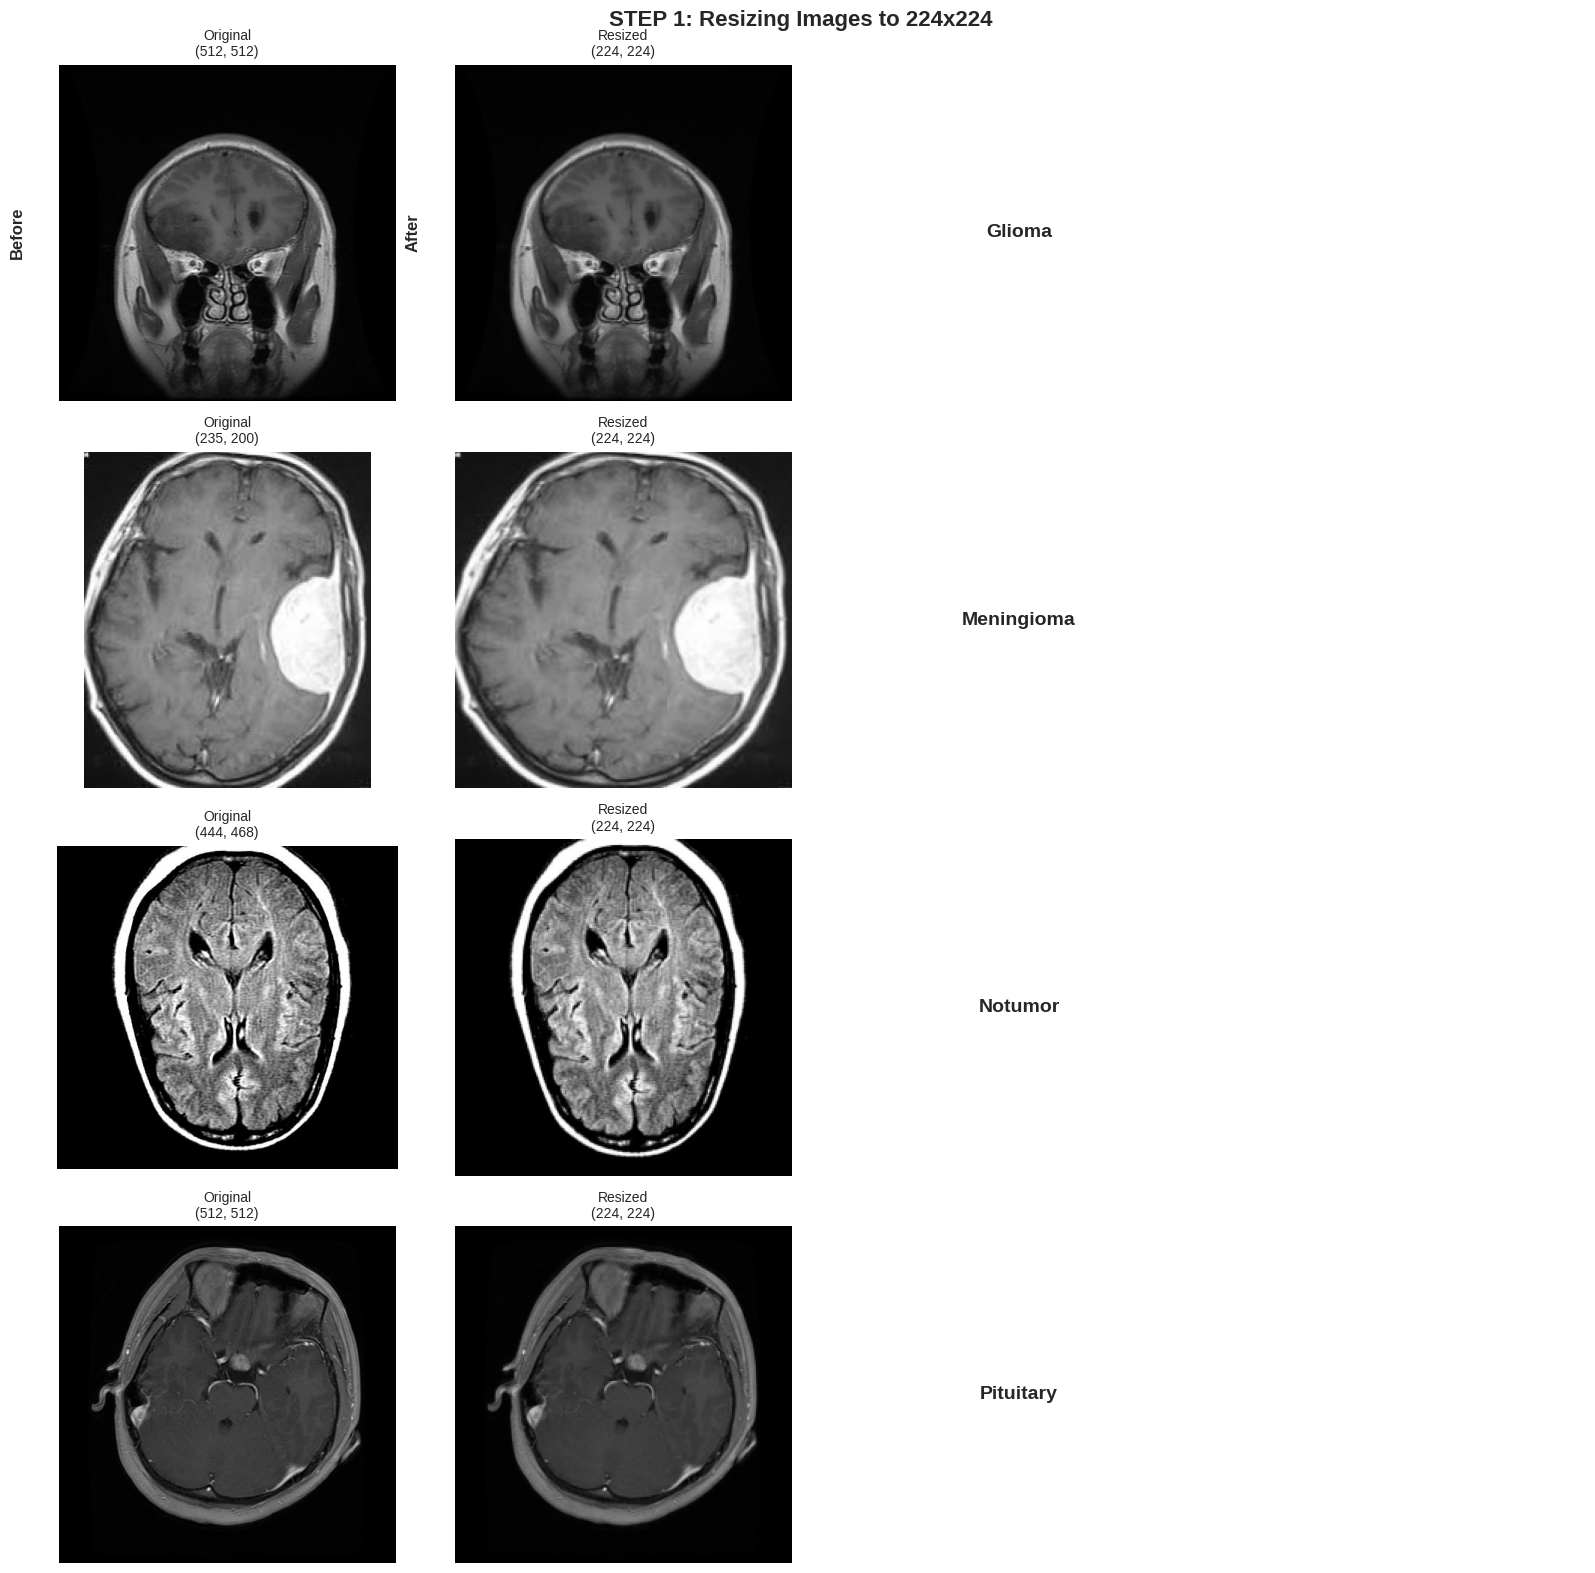


✓ All images resized to (224, 224)
✓ Aspect ratio preserved using INTER_AREA interpolation


In [ ]:
# PREPROCESSING - Step 1: Resizing
print("\n" + "=" * 60)
print("PREPROCESSING STEP 1: IMAGE RESIZING")
print("=" * 60)

# Define target size
TARGET_SIZE = (224, 224)

def resize_image(img, target_size=TARGET_SIZE):
    """Resize image to target size"""
    return cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)

# Demonstrate resizing on sample images
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle('STEP 1: Resizing Images to 224x224', fontsize=16, fontweight='bold')

for i, category in enumerate(categories):
    category_path = os.path.join(training_path, category)
    image_files = [f for f in os.listdir(category_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
    sample = image_files[0]

    img_path = os.path.join(category_path, sample)
    img_original = cv2.imread(img_path)
    img_original_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
    img_resized = resize_image(img_original)
    img_resized_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

    # Original
    axes[i, 0].imshow(img_original_rgb)
    axes[i, 0].set_title(f'Original\n{img_original.shape[:2]}', fontsize=10)
    axes[i, 0].axis('off')
    if i == 0:
        axes[i, 0].text(-0.1, 0.5, 'Before', transform=axes[i, 0].transAxes,
                       rotation=90, va='center', ha='right', fontsize=12, fontweight='bold')

    # Resized
    axes[i, 1].imshow(img_resized_rgb)
    axes[i, 1].set_title(f'Resized\n{img_resized.shape[:2]}', fontsize=10)
    axes[i, 1].axis('off')
    if i == 0:
        axes[i, 1].text(-0.1, 0.5, 'After', transform=axes[i, 1].transAxes,
                       rotation=90, va='center', ha='right', fontsize=12, fontweight='bold')

    # Category label
    axes[i, 2].text(0.5, 0.5, category.capitalize(),
                   transform=axes[i, 2].transAxes,
                   ha='center', va='center', fontsize=14, fontweight='bold')
    axes[i, 2].axis('off')

    # Hide the 4th column
    axes[i, 3].axis('off')

plt.tight_layout()
plt.show()

print(f"\n✓ All images resized to {TARGET_SIZE}")
print(f"✓ Aspect ratio preserved using INTER_AREA interpolation")



PREPROCESSING STEP 2: GRAYSCALE CONVERSION


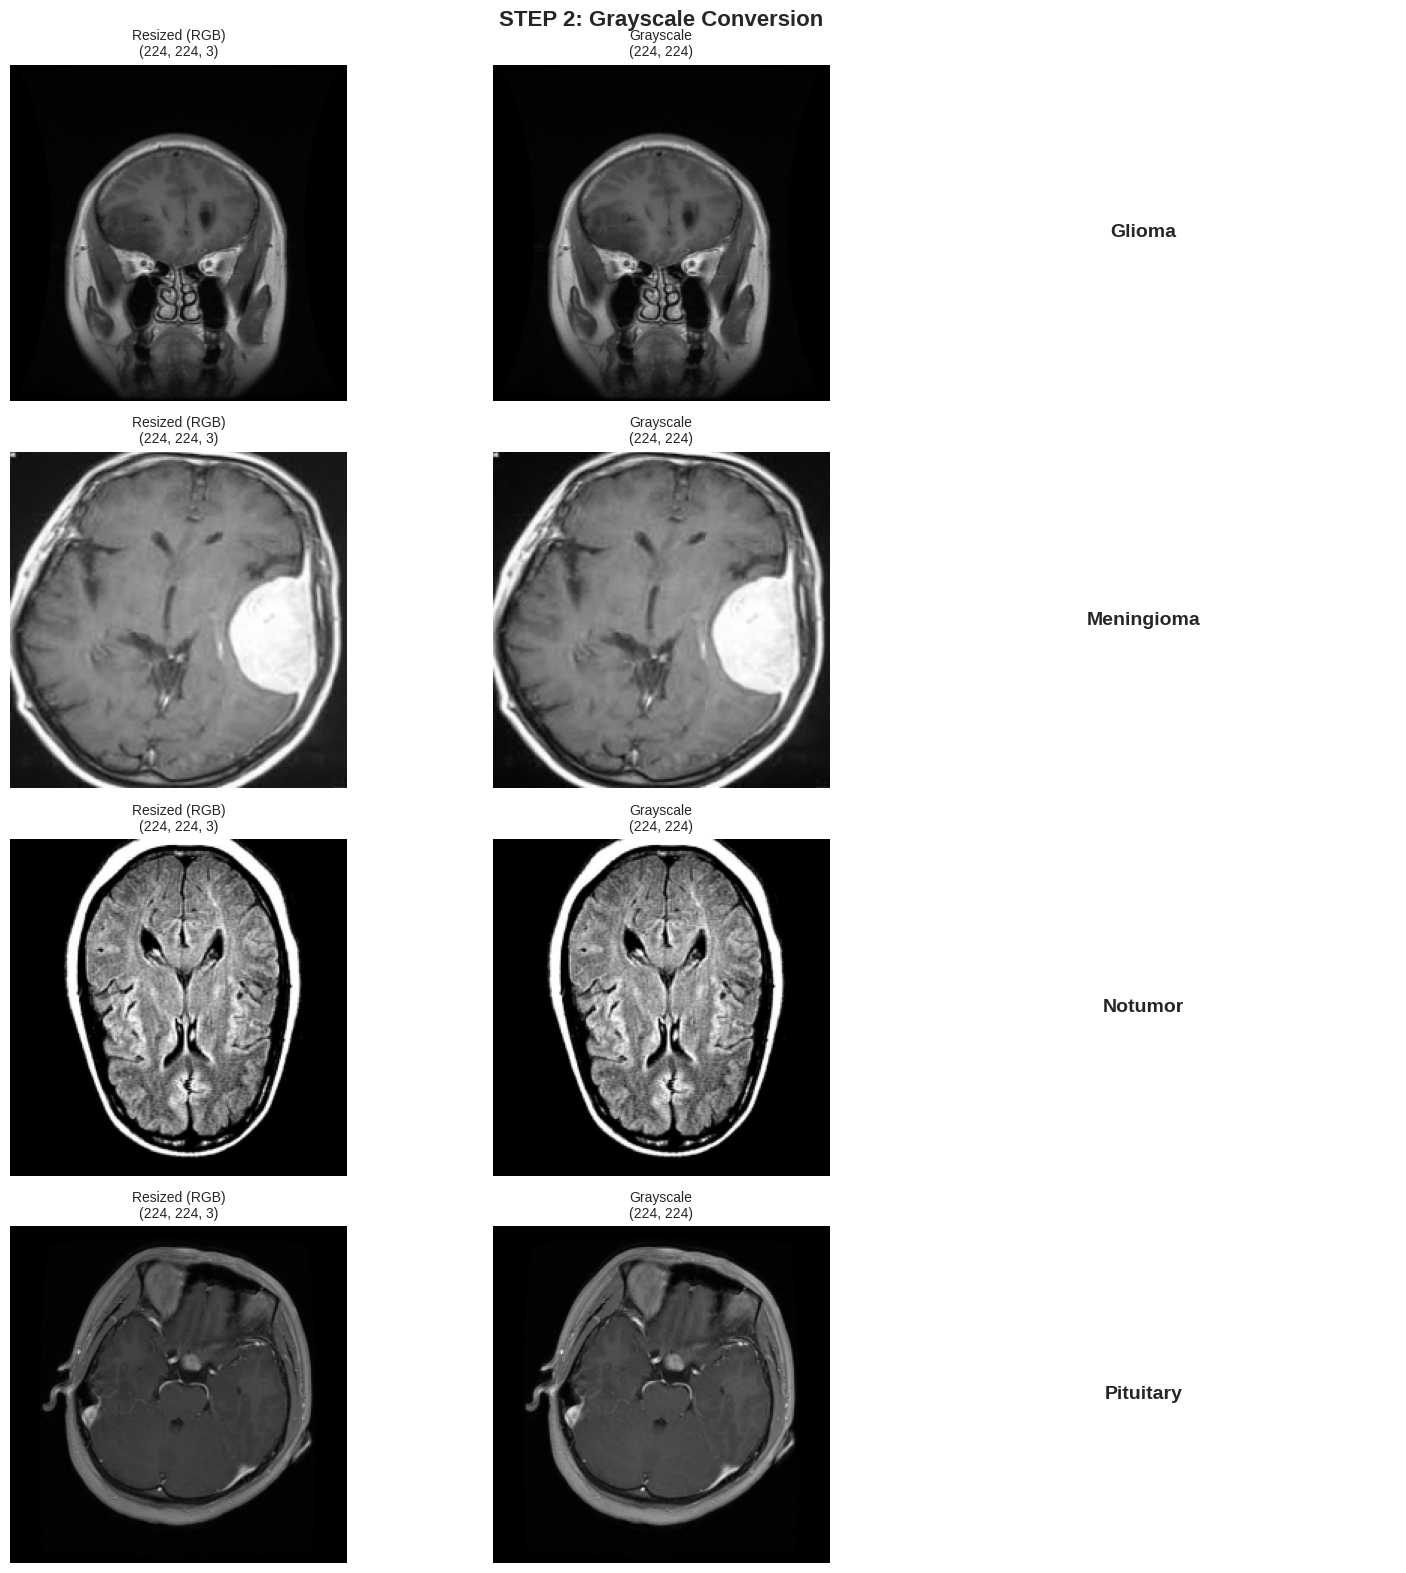


✓ Images converted to grayscale
✓ Reduced from 3 channels (RGB) to 1 channel (Grayscale)
✓ Reduces computational complexity while retaining structural information


In [ ]:
# PREPROCESSING - Step 2: Grayscale Conversion
print("\n" + "=" * 60)
print("PREPROCESSING STEP 2: GRAYSCALE CONVERSION")
print("=" * 60)

def convert_to_grayscale(img):
    """Convert image to grayscale"""
    if len(img.shape) == 3:
        return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img

# Demonstrate grayscale conversion
fig, axes = plt.subplots(4, 3, figsize=(15, 16))
fig.suptitle('STEP 2: Grayscale Conversion', fontsize=16, fontweight='bold')

for i, category in enumerate(categories):
    category_path = os.path.join(training_path, category)
    image_files = [f for f in os.listdir(category_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
    sample = image_files[0]

    img_path = os.path.join(category_path, sample)
    img = cv2.imread(img_path)
    img_resized = resize_image(img)
    img_gray = convert_to_grayscale(img_resized)

    # Original (resized, color)
    axes[i, 0].imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title(f'Resized (RGB)\n{img_resized.shape}', fontsize=10)
    axes[i, 0].axis('off')

    # Grayscale
    axes[i, 1].imshow(img_gray, cmap='gray')
    axes[i, 1].set_title(f'Grayscale\n{img_gray.shape}', fontsize=10)
    axes[i, 1].axis('off')

    # Category label
    axes[i, 2].text(0.5, 0.5, category.capitalize(),
                   transform=axes[i, 2].transAxes,
                   ha='center', va='center', fontsize=14, fontweight='bold')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

print("\n✓ Images converted to grayscale")
print("✓ Reduced from 3 channels (RGB) to 1 channel (Grayscale)")
print("✓ Reduces computational complexity while retaining structural information")



PREPROCESSING STEP 3: PIXEL NORMALIZATION


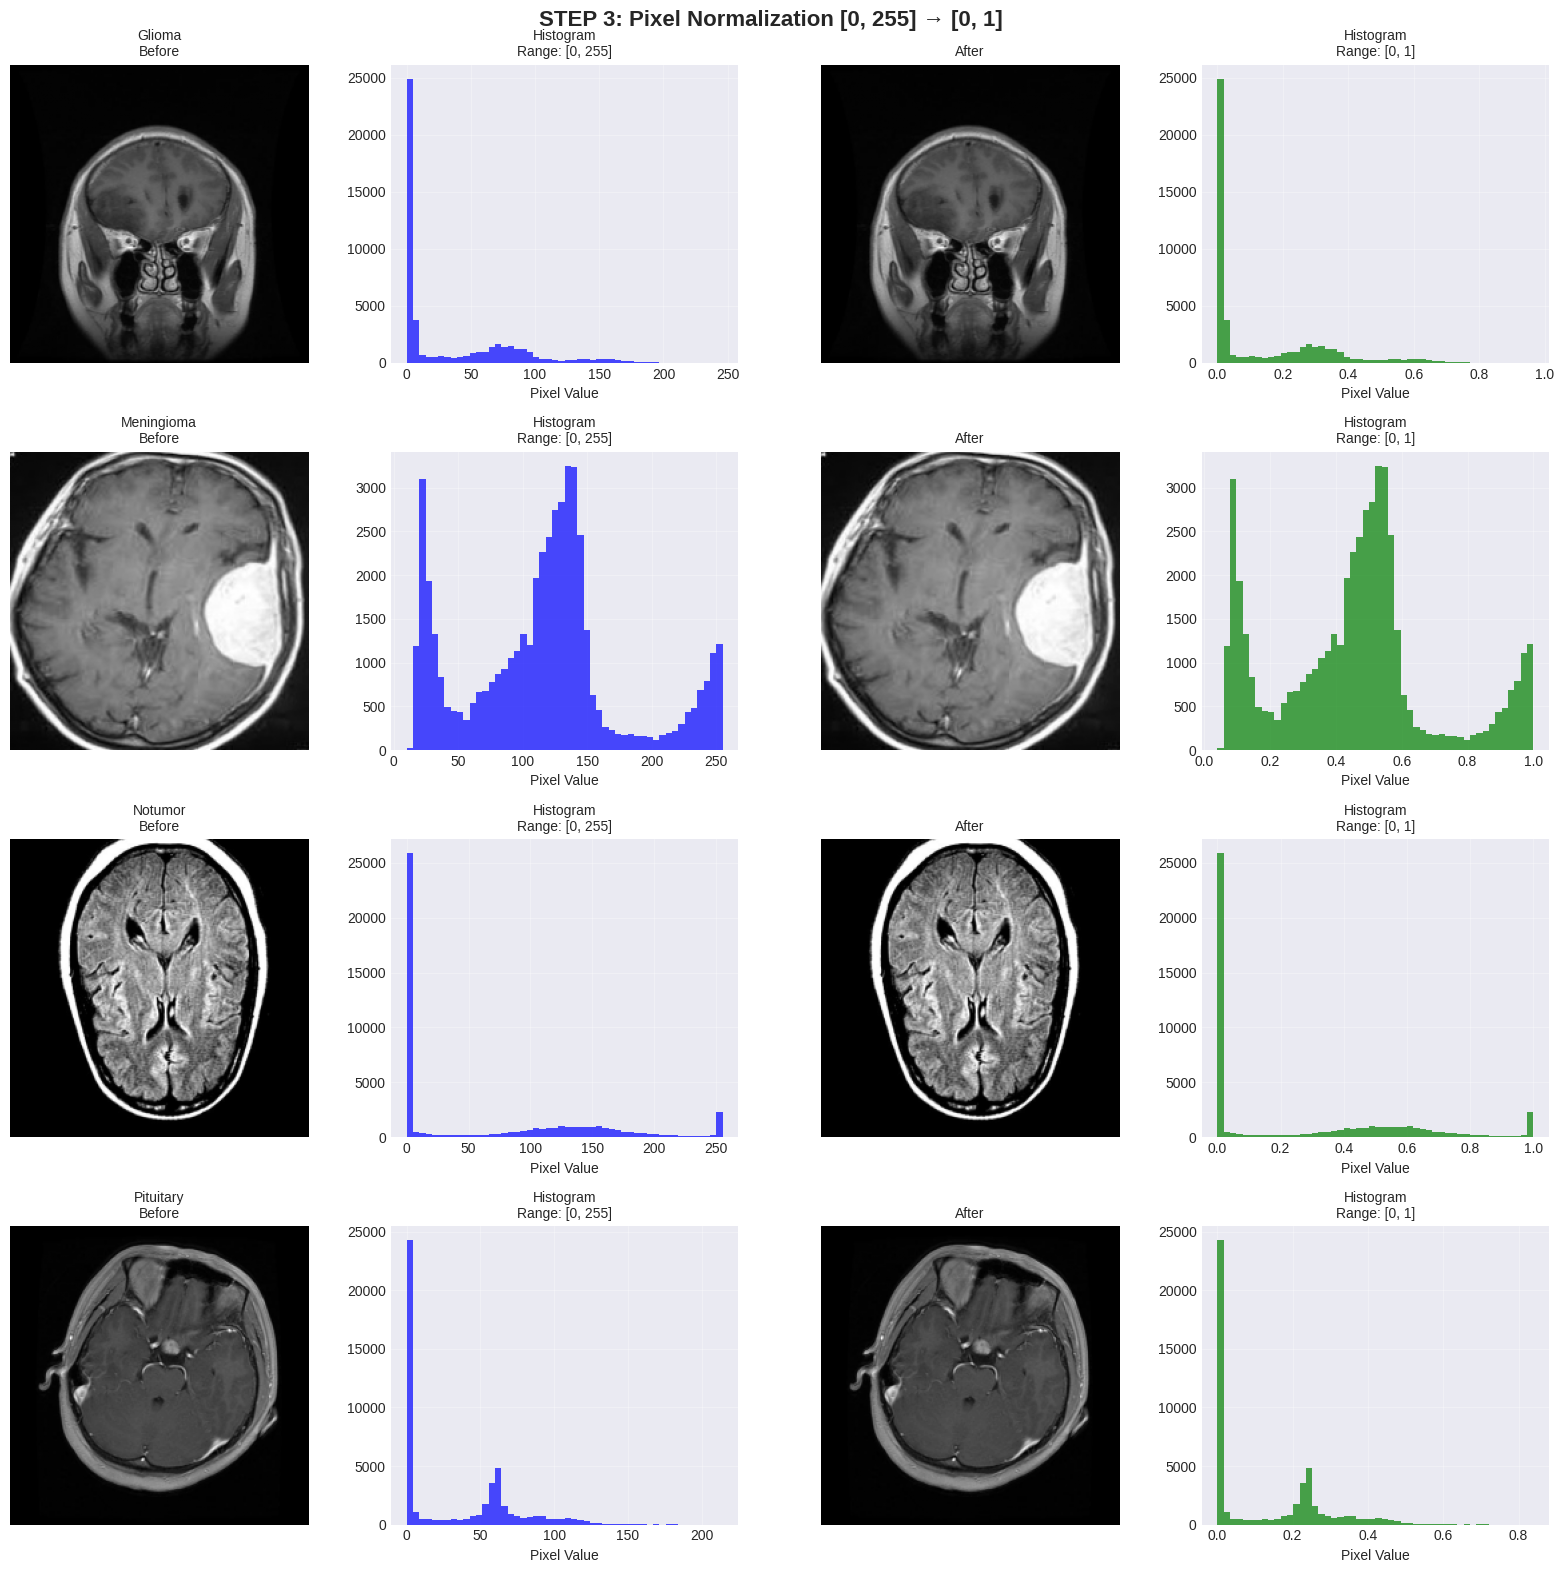


Normalization Statistics:
------------------------------------------------------------
Glioma:
  Before: min=0, max=246, mean=35.52
  After:  min=0.0000, max=0.9647, mean=0.1393
Meningioma:
  Before: min=10, max=255, mean=116.38
  After:  min=0.0392, max=1.0000, mean=0.4564
Notumor:
  Before: min=0, max=255, mean=67.61
  After:  min=0.0000, max=1.0000, mean=0.2651
Pituitary:
  Before: min=0, max=214, mean=33.37
  After:  min=0.0000, max=0.8392, mean=0.1309

✓ Pixel values normalized to range [0, 1]
✓ Improves model convergence and training stability


In [ ]:
# PREPROCESSING - Step 3: Normalization
print("\n" + "=" * 60)
print("PREPROCESSING STEP 3: PIXEL NORMALIZATION")
print("=" * 60)

def normalize_image(img):
    """Normalize pixel values to [0, 1]"""
    return img.astype(np.float32) / 255.0

# Demonstrate normalization with histograms
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle('STEP 3: Pixel Normalization [0, 255] → [0, 1]', fontsize=16, fontweight='bold')

for i, category in enumerate(categories):
    category_path = os.path.join(training_path, category)
    image_files = [f for f in os.listdir(category_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
    sample = image_files[0]

    img_path = os.path.join(category_path, sample)
    img = cv2.imread(img_path)
    img_resized = resize_image(img)
    img_gray = convert_to_grayscale(img_resized)
    img_normalized = normalize_image(img_gray)

    # Before normalization
    axes[i, 0].imshow(img_gray, cmap='gray')
    axes[i, 0].set_title(f'{category.capitalize()}\nBefore', fontsize=10)
    axes[i, 0].axis('off')

    # Histogram before
    axes[i, 1].hist(img_gray.ravel(), bins=50, color='blue', alpha=0.7)
    axes[i, 1].set_title('Histogram\nRange: [0, 255]', fontsize=10)
    axes[i, 1].set_xlabel('Pixel Value')
    axes[i, 1].grid(True, alpha=0.3)

    # After normalization
    axes[i, 2].imshow(img_normalized, cmap='gray')
    axes[i, 2].set_title('After', fontsize=10)
    axes[i, 2].axis('off')

    # Histogram after
    axes[i, 3].hist(img_normalized.ravel(), bins=50, color='green', alpha=0.7)
    axes[i, 3].set_title('Histogram\nRange: [0, 1]', fontsize=10)
    axes[i, 3].set_xlabel('Pixel Value')
    axes[i, 3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("\nNormalization Statistics:")
print("-" * 60)
for category in categories:
    category_path = os.path.join(training_path, category)
    image_files = [f for f in os.listdir(category_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
    sample = image_files[0]

    img_path = os.path.join(category_path, sample)
    img = cv2.imread(img_path)
    img_processed = convert_to_grayscale(resize_image(img))
    img_normalized = normalize_image(img_processed)

    print(f"{category.capitalize()}:")
    print(f"  Before: min={img_processed.min()}, max={img_processed.max()}, mean={img_processed.mean():.2f}")
    print(f"  After:  min={img_normalized.min():.4f}, max={img_normalized.max():.4f}, mean={img_normalized.mean():.4f}")

print("\n✓ Pixel values normalized to range [0, 1]")
print("✓ Improves model convergence and training stability")



PREPROCESSING STEP 4: HISTOGRAM EQUALIZATION


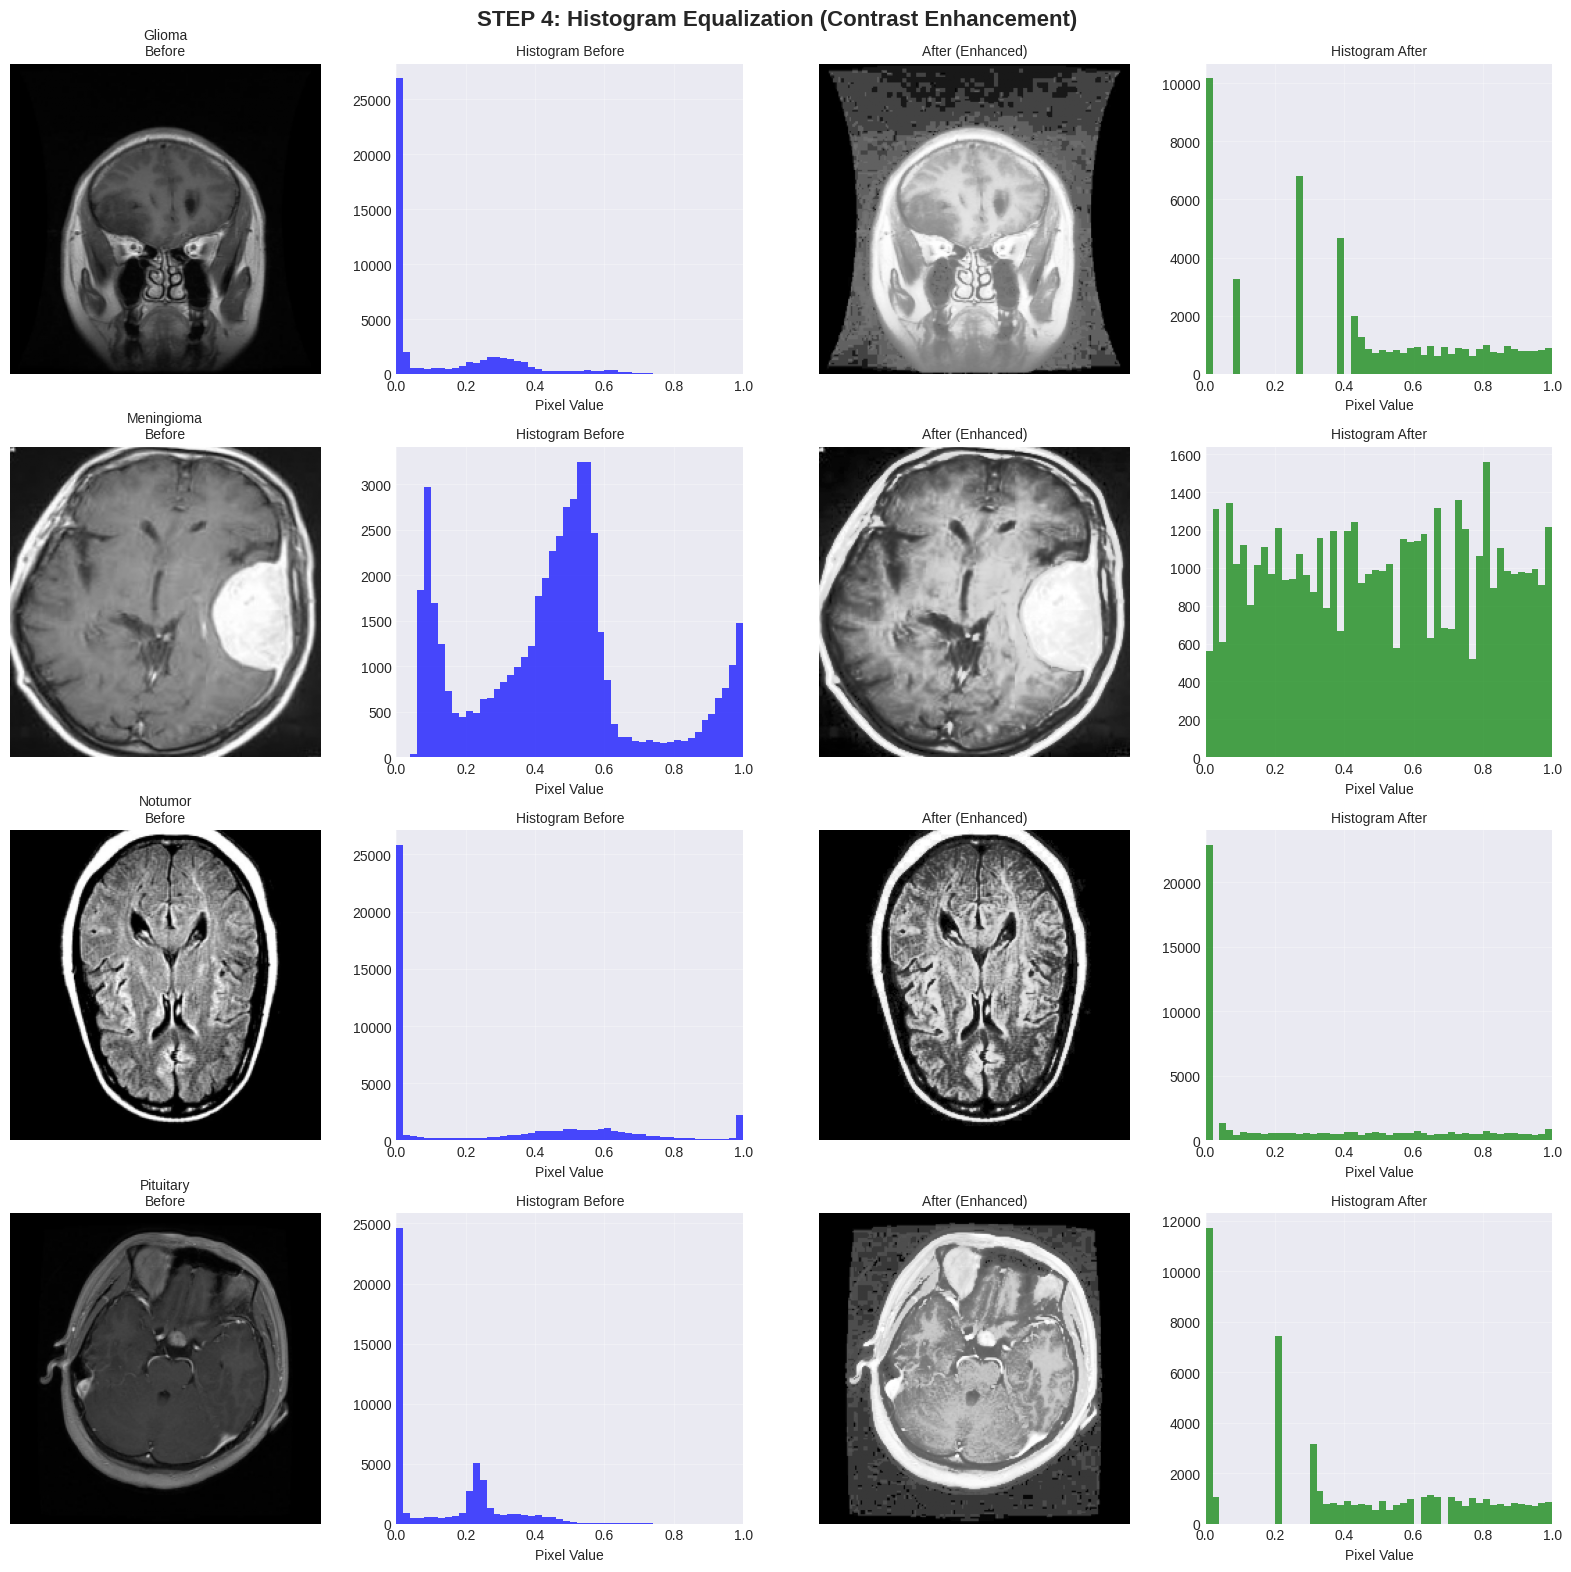


✓ Histogram equalization applied
✓ Contrast enhanced by spreading out intensity values
✓ Improves visibility of features in brain scans


In [ ]:
# PREPROCESSING - Step 4: Histogram Equalization (Contrast Enhancement)
print("\n" + "=" * 60)
print("PREPROCESSING STEP 4: HISTOGRAM EQUALIZATION")
print("=" * 60)

def equalize_histogram(img):
    """Apply histogram equalization for contrast enhancement"""
    # Convert to uint8 if needed
    if img.dtype == np.float32 or img.dtype == np.float64:
        img_uint8 = (img * 255).astype(np.uint8)
    else:
        img_uint8 = img

    # Apply histogram equalization
    equalized = cv2.equalizeHist(img_uint8)

    # Convert back to float32 normalized
    return equalized.astype(np.float32) / 255.0

# Demonstrate histogram equalization
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle('STEP 4: Histogram Equalization (Contrast Enhancement)', fontsize=16, fontweight='bold')

for i, category in enumerate(categories):
    category_path = os.path.join(training_path, category)
    image_files = [f for f in os.listdir(category_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
    sample = image_files[0]

    img_path = os.path.join(category_path, sample)
    img = cv2.imread(img_path)
    img_processed = normalize_image(convert_to_grayscale(resize_image(img)))
    img_equalized = equalize_histogram(img_processed)

    # Before equalization
    axes[i, 0].imshow(img_processed, cmap='gray', vmin=0, vmax=1)
    axes[i, 0].set_title(f'{category.capitalize()}\nBefore', fontsize=10)
    axes[i, 0].axis('off')

    # Histogram before
    axes[i, 1].hist(img_processed.ravel(), bins=50, color='blue', alpha=0.7, range=(0, 1))
    axes[i, 1].set_title('Histogram Before', fontsize=10)
    axes[i, 1].set_xlabel('Pixel Value')
    axes[i, 1].set_xlim(0, 1)
    axes[i, 1].grid(True, alpha=0.3)

    # After equalization
    axes[i, 2].imshow(img_equalized, cmap='gray', vmin=0, vmax=1)
    axes[i, 2].set_title('After (Enhanced)', fontsize=10)
    axes[i, 2].axis('off')

    # Histogram after
    axes[i, 3].hist(img_equalized.ravel(), bins=50, color='green', alpha=0.7, range=(0, 1))
    axes[i, 3].set_title('Histogram After', fontsize=10)
    axes[i, 3].set_xlabel('Pixel Value')
    axes[i, 3].set_xlim(0, 1)
    axes[i, 3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Histogram equalization applied")
print("✓ Contrast enhanced by spreading out intensity values")
print("✓ Improves visibility of features in brain scans")



PREPROCESSING STEP 5: NOISE REDUCTION (GAUSSIAN BLUR)


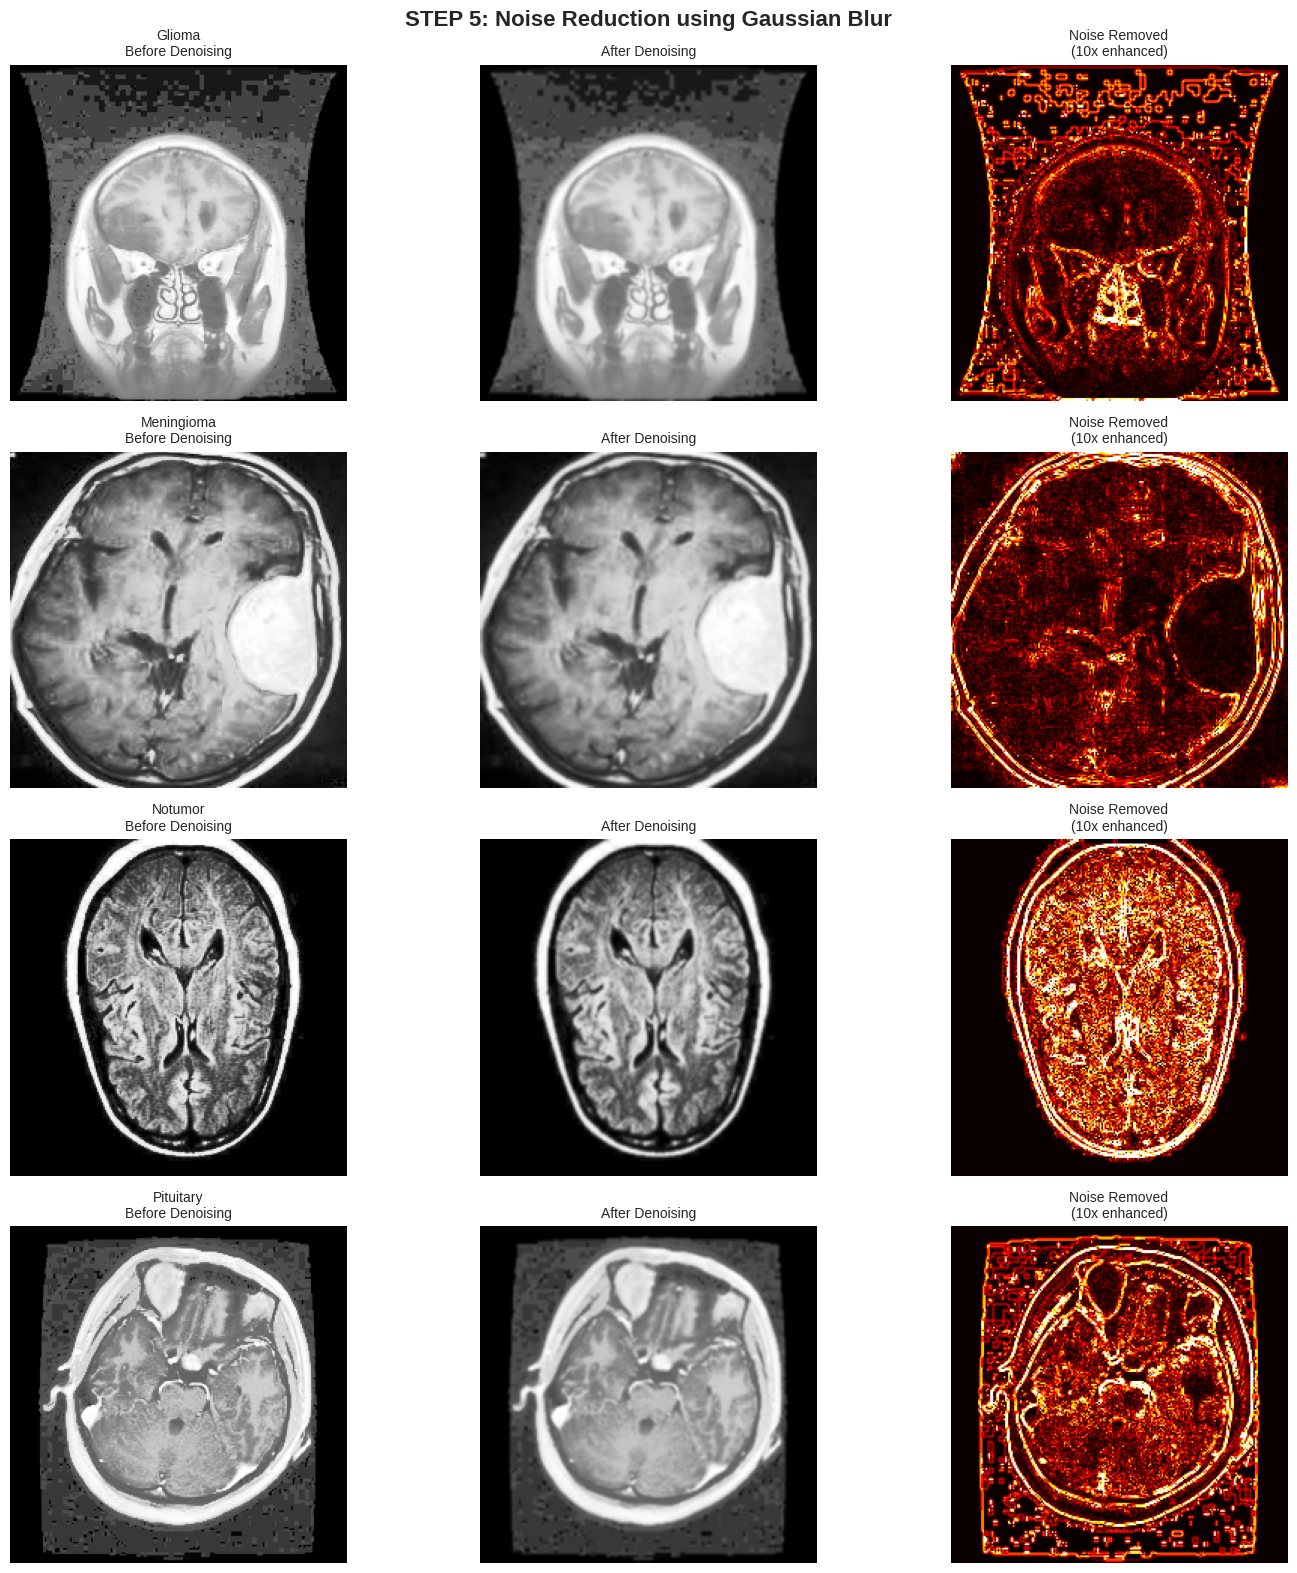


✓ Gaussian blur applied for noise reduction
✓ Smooths out noise while preserving edges
✓ Kernel size: 3x3


In [ ]:
# PREPROCESSING - Step 5: Noise Reduction
print("\n" + "=" * 60)
print("PREPROCESSING STEP 5: NOISE REDUCTION (GAUSSIAN BLUR)")
print("=" * 60)

def reduce_noise(img, kernel_size=(3, 3)):
    """Apply Gaussian blur for noise reduction"""
    # Convert to uint8 if needed for OpenCV
    if img.dtype == np.float32 or img.dtype == np.float64:
        img_uint8 = (img * 255).astype(np.uint8)
    else:
        img_uint8 = img

    # Apply Gaussian blur
    blurred = cv2.GaussianBlur(img_uint8, kernel_size, 0)

    # Convert back to float32 normalized
    return blurred.astype(np.float32) / 255.0

# Demonstrate noise reduction
fig, axes = plt.subplots(4, 3, figsize=(15, 16))
fig.suptitle('STEP 5: Noise Reduction using Gaussian Blur', fontsize=16, fontweight='bold')

for i, category in enumerate(categories):
    category_path = os.path.join(training_path, category)
    image_files = [f for f in os.listdir(category_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
    sample = image_files[0]

    img_path = os.path.join(category_path, sample)
    img = cv2.imread(img_path)
    img_processed = equalize_histogram(normalize_image(convert_to_grayscale(resize_image(img))))
    img_denoised = reduce_noise(img_processed)

    # Before noise reduction
    axes[i, 0].imshow(img_processed, cmap='gray', vmin=0, vmax=1)
    axes[i, 0].set_title(f'{category.capitalize()}\nBefore Denoising', fontsize=10)
    axes[i, 0].axis('off')

    # After noise reduction
    axes[i, 1].imshow(img_denoised, cmap='gray', vmin=0, vmax=1)
    axes[i, 1].set_title('After Denoising', fontsize=10)
    axes[i, 1].axis('off')

    # Difference (exaggerated)
    diff = np.abs(img_processed - img_denoised) * 10  # Multiply to make visible
    axes[i, 2].imshow(diff, cmap='hot', vmin=0, vmax=1)
    axes[i, 2].set_title('Noise Removed\n(10x enhanced)', fontsize=10)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

print("\n✓ Gaussian blur applied for noise reduction")
print("✓ Smooths out noise while preserving edges")
print("✓ Kernel size: 3x3")


## Complete Preprocessing Pipeline - Side-by-Side Comparison

Let's visualize the complete transformation from original to fully preprocessed images.


COMPLETE PREPROCESSING PIPELINE


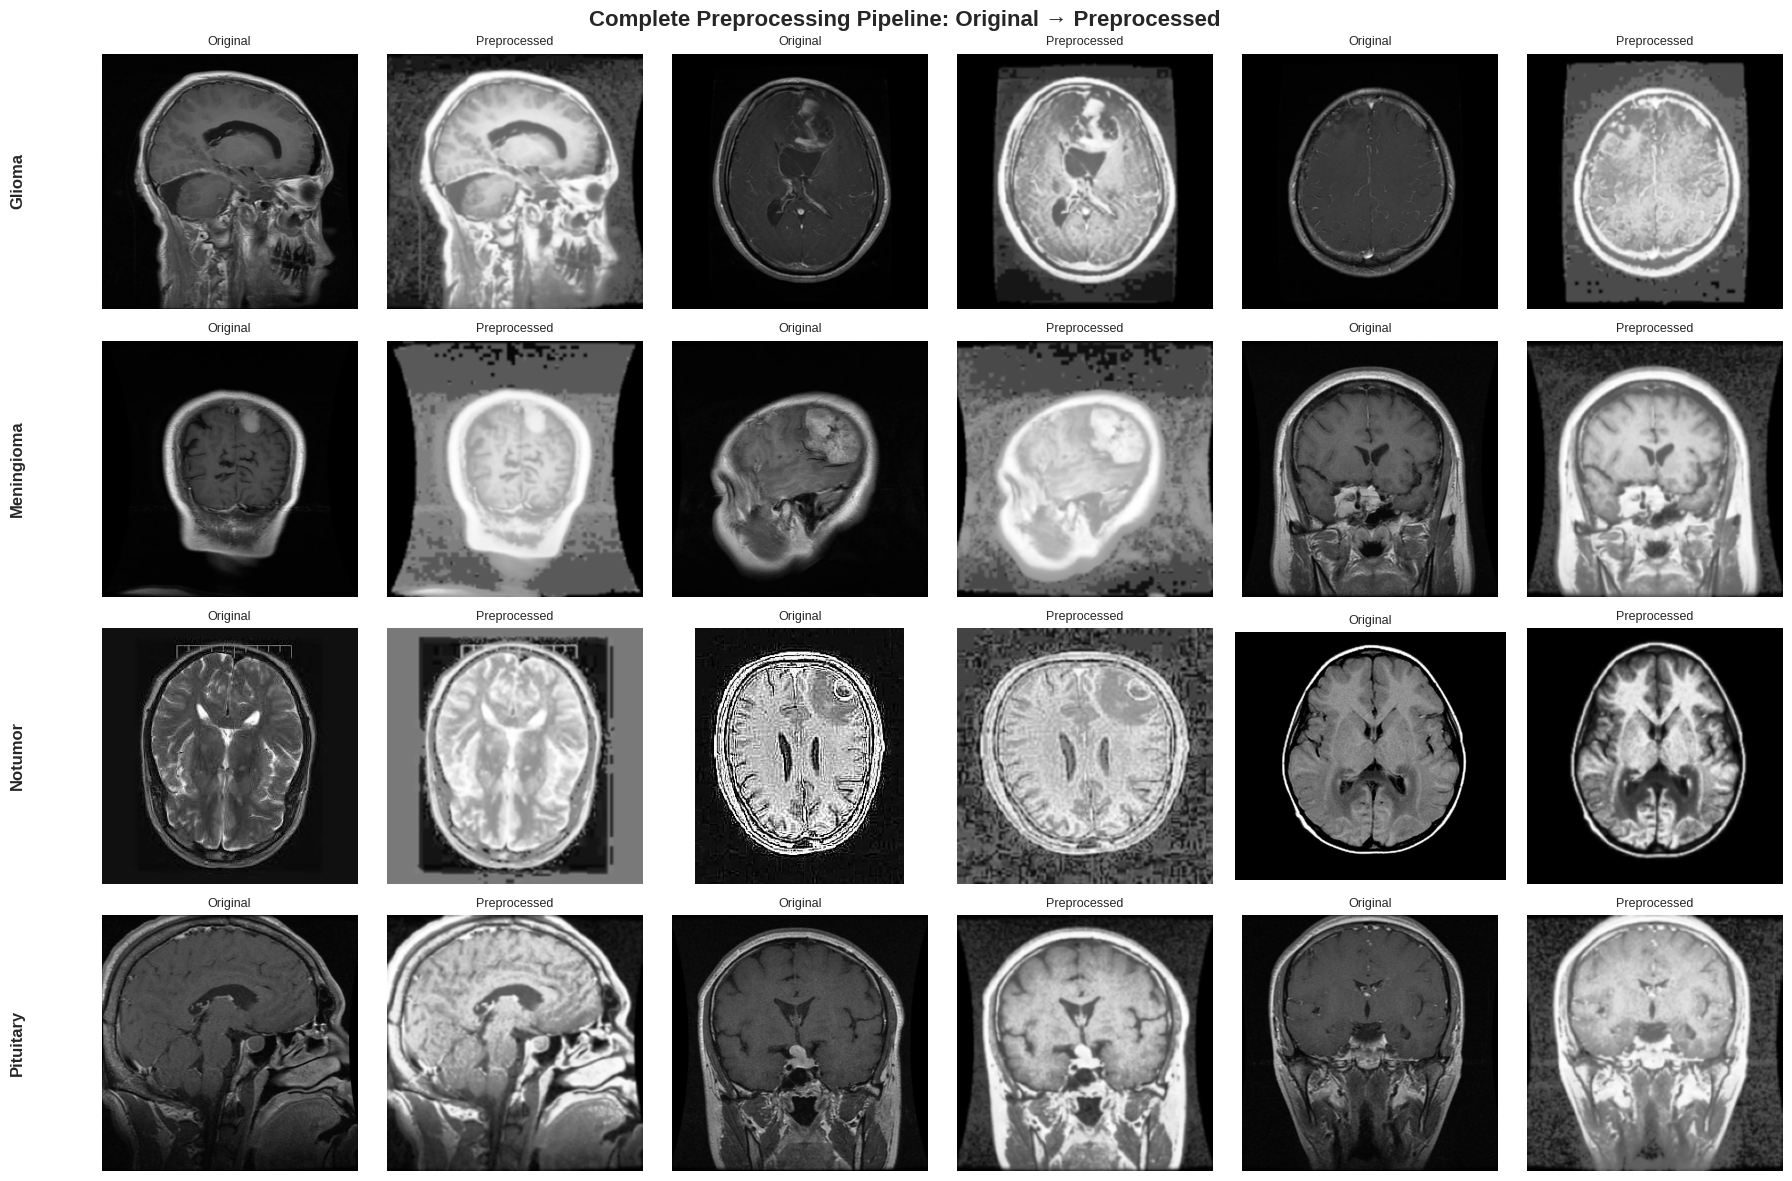


PREPROCESSING PIPELINE SUMMARY

✓ Step 1: Resized to 224x224
✓ Step 2: Converted to grayscale
✓ Step 3: Normalized to [0, 1]
✓ Step 4: Enhanced contrast (histogram equalization)
✓ Step 5: Reduced noise (Gaussian blur)

Dataset is now ready for model training!


In [ ]:
# Complete Preprocessing Pipeline Function
def preprocess_pipeline(img_path, target_size=(224, 224)):
    """
    Complete preprocessing pipeline for brain tumor images

    Steps:
    1. Load image
    2. Resize to target size
    3. Convert to grayscale
    4. Normalize to [0, 1]
    5. Apply histogram equalization
    6. Reduce noise

    Returns:
        Preprocessed image as numpy array
    """
    # Load image
    img = cv2.imread(img_path)

    # Step 1: Resize
    img = resize_image(img, target_size)

    # Step 2: Convert to grayscale
    img = convert_to_grayscale(img)

    # Step 3: Normalize
    img = normalize_image(img)

    # Step 4: Histogram equalization
    img = equalize_histogram(img)

    # Step 5: Noise reduction
    img = reduce_noise(img)

    return img

# Demonstrate complete pipeline on multiple samples
print("\n" + "=" * 60)
print("COMPLETE PREPROCESSING PIPELINE")
print("=" * 60)

fig, axes = plt.subplots(4, 6, figsize=(18, 12))
fig.suptitle('Complete Preprocessing Pipeline: Original → Preprocessed', fontsize=16, fontweight='bold')

for i, category in enumerate(categories):
    category_path = os.path.join(training_path, category)
    image_files = [f for f in os.listdir(category_path) if f.endswith(('.jpg', '.png', '.jpeg'))]

    # Process 3 samples from each category
    samples = np.random.choice(image_files, min(3, len(image_files)), replace=False)

    for j, sample in enumerate(samples):
        img_path = os.path.join(category_path, sample)

        # Original image
        img_original = cv2.imread(img_path)
        img_original_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

        # Preprocessed image
        img_preprocessed = preprocess_pipeline(img_path)

        # Display original
        axes[i, j*2].imshow(img_original_rgb)
        axes[i, j*2].set_title(f'Original', fontsize=9)
        axes[i, j*2].axis('off')

        # Display preprocessed
        axes[i, j*2+1].imshow(img_preprocessed, cmap='gray', vmin=0, vmax=1)
        axes[i, j*2+1].set_title(f'Preprocessed', fontsize=9)
        axes[i, j*2+1].axis('off')

        # Add category label on first column
        if j == 0:
            axes[i, 0].text(-0.3, 0.5, category.capitalize(),
                          transform=axes[i, 0].transAxes,
                          rotation=90, va='center', ha='right',
                          fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("PREPROCESSING PIPELINE SUMMARY")
print("=" * 60)
print("\n✓ Step 1: Resized to 224x224")
print("✓ Step 2: Converted to grayscale")
print("✓ Step 3: Normalized to [0, 1]")
print("✓ Step 4: Enhanced contrast (histogram equalization)")
print("✓ Step 5: Reduced noise (Gaussian blur)")
print("\n" + "=" * 60)
print("Dataset is now ready for model training!")
print("=" * 60)


## Final Analysis: Preprocessing Impact Metrics

Let's quantify the impact of preprocessing on image quality metrics.


PREPROCESSING IMPACT ANALYSIS

Preprocessing Impact Metrics:
------------------------------------------------------------
  category  mean_before  mean_after  std_before  std_after  contrast_before  contrast_after
    glioma    32.666846    0.415579   38.157671   0.304819           231.60        0.998039
meningioma    42.996481    0.431543   46.093166   0.304157           239.40        0.999020
   notumor    60.936130    0.427578   63.478034   0.282025           246.90        0.994314
 pituitary    48.369625    0.467683   40.695150   0.289417           234.45        0.998431


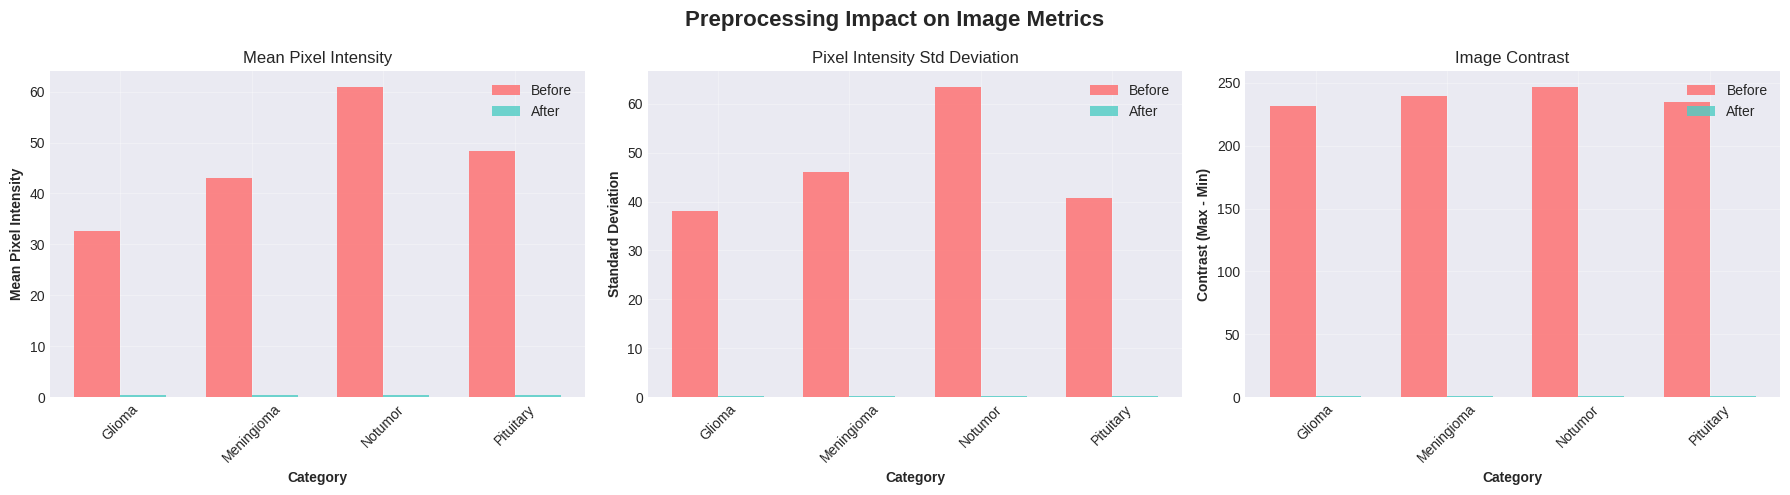


IMPROVEMENT ANALYSIS

Glioma:
  Contrast improvement: -99.57%
  Std deviation change: -99.20%

Meningioma:
  Contrast improvement: -99.58%
  Std deviation change: -99.34%

Notumor:
  Contrast improvement: -99.60%
  Std deviation change: -99.56%

Pituitary:
  Contrast improvement: -99.57%
  Std deviation change: -99.29%


In [ ]:
# Final Analysis: Preprocessing Impact
print("\n" + "=" * 60)
print("PREPROCESSING IMPACT ANALYSIS")
print("=" * 60)

# Collect metrics before and after preprocessing
metrics_data = {
    'category': [],
    'mean_before': [],
    'mean_after': [],
    'std_before': [],
    'std_after': [],
    'contrast_before': [],
    'contrast_after': []
}

for category in categories:
    category_path = os.path.join(training_path, category)
    image_files = [f for f in os.listdir(category_path) if f.endswith(('.jpg', '.png', '.jpeg'))]

    # Sample 20 images
    samples = np.random.choice(image_files, min(20, len(image_files)), replace=False)

    means_before, means_after = [], []
    stds_before, stds_after = [], []
    contrasts_before, contrasts_after = [], []

    for sample in samples:
        img_path = os.path.join(category_path, sample)

        # Original (just grayscale and resized)
        img_before = convert_to_grayscale(resize_image(cv2.imread(img_path)))

        # Fully preprocessed
        img_after = preprocess_pipeline(img_path)

        # Calculate metrics
        means_before.append(np.mean(img_before))
        means_after.append(np.mean(img_after))

        stds_before.append(np.std(img_before))
        stds_after.append(np.std(img_after))

        # Contrast (max - min)
        contrasts_before.append(np.max(img_before) - np.min(img_before))
        contrasts_after.append(np.max(img_after) - np.min(img_after))

    metrics_data['category'].append(category)
    metrics_data['mean_before'].append(np.mean(means_before))
    metrics_data['mean_after'].append(np.mean(means_after))
    metrics_data['std_before'].append(np.mean(stds_before))
    metrics_data['std_after'].append(np.mean(stds_after))
    metrics_data['contrast_before'].append(np.mean(contrasts_before))
    metrics_data['contrast_after'].append(np.mean(contrasts_after))

# Create DataFrame
df_metrics = pd.DataFrame(metrics_data)

# Display metrics
print("\nPreprocessing Impact Metrics:")
print("-" * 60)
print(df_metrics.to_string(index=False))

# Visualize the impact
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Preprocessing Impact on Image Metrics', fontsize=16, fontweight='bold')

# Mean intensity comparison
x = np.arange(len(categories))
width = 0.35
axes[0].bar(x - width/2, df_metrics['mean_before'], width, label='Before', alpha=0.8, color='#FF6B6B')
axes[0].bar(x + width/2, df_metrics['mean_after'], width, label='After', alpha=0.8, color='#4ECDC4')
axes[0].set_xlabel('Category', fontweight='bold')
axes[0].set_ylabel('Mean Pixel Intensity', fontweight='bold')
axes[0].set_title('Mean Pixel Intensity')
axes[0].set_xticks(x)
axes[0].set_xticklabels([cat.capitalize() for cat in categories], rotation=45)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Standard deviation comparison
axes[1].bar(x - width/2, df_metrics['std_before'], width, label='Before', alpha=0.8, color='#FF6B6B')
axes[1].bar(x + width/2, df_metrics['std_after'], width, label='After', alpha=0.8, color='#4ECDC4')
axes[1].set_xlabel('Category', fontweight='bold')
axes[1].set_ylabel('Standard Deviation', fontweight='bold')
axes[1].set_title('Pixel Intensity Std Deviation')
axes[1].set_xticks(x)
axes[1].set_xticklabels([cat.capitalize() for cat in categories], rotation=45)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Contrast comparison
axes[2].bar(x - width/2, df_metrics['contrast_before'], width, label='Before', alpha=0.8, color='#FF6B6B')
axes[2].bar(x + width/2, df_metrics['contrast_after'], width, label='After', alpha=0.8, color='#4ECDC4')
axes[2].set_xlabel('Category', fontweight='bold')
axes[2].set_ylabel('Contrast (Max - Min)', fontweight='bold')
axes[2].set_title('Image Contrast')
axes[2].set_xticks(x)
axes[2].set_xticklabels([cat.capitalize() for cat in categories], rotation=45)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate improvement percentages
print("\n" + "=" * 60)
print("IMPROVEMENT ANALYSIS")
print("=" * 60)
for i, category in enumerate(categories):
    contrast_improvement = ((df_metrics['contrast_after'][i] - df_metrics['contrast_before'][i])
                            / df_metrics['contrast_before'][i] * 100)
    std_change = ((df_metrics['std_after'][i] - df_metrics['std_before'][i])
                  / df_metrics['std_before'][i] * 100)

    print(f"\n{category.capitalize()}:")
    print(f"  Contrast improvement: {contrast_improvement:+.2f}%")
    print(f"  Std deviation change: {std_change:+.2f}%")


In [ ]:
# Save preprocessed dataset to the requested folder
preprocessed_root = r'/content/preprocessed/brain-tumor'

# Process both training and testing sets
for src_root, split_name in [(training_path, 'Training'), (testing_path, 'Testing')]:
    for category in categories:
        src_cat = os.path.join(src_root, category)
        dest_cat = os.path.join(preprocessed_root, split_name, category)
        os.makedirs(dest_cat, exist_ok=True)

        if not os.path.exists(src_cat):
            print(f"Source folder not found, skipping: {src_cat}")
            continue

        image_files = [f for f in os.listdir(src_cat) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        print(f"Processing {len(image_files)} images -> {dest_cat}")

        saved = 0
        for img_file in image_files:
            src_path = os.path.join(src_cat, img_file)
            try:
                img_pp = preprocess_pipeline(src_path)  # returns float32 in [0,1], grayscale (224x224)
                # Convert back to uint8 for saving
                img_uint8 = (img_pp * 255.0).clip(0, 255).astype(np.uint8)
                dst_path = os.path.join(dest_cat, img_file)
                # cv2.imwrite handles single-channel images correctly
                ok = cv2.imwrite(dst_path, img_uint8)
                if ok:
                    saved += 1
                else:
                    print(f"Failed to write: {dst_path}")
            except Exception as e:
                print(f"Error processing {src_path}: {e}")

        print(f"Saved {saved}/{len(image_files)} images to {dest_cat}")

Processing 1321 images -> /content/preprocessed/brain-tumor/Training/glioma
Saved 1321/1321 images to /content/preprocessed/brain-tumor/Training/glioma
Processing 1339 images -> /content/preprocessed/brain-tumor/Training/meningioma
Saved 1339/1339 images to /content/preprocessed/brain-tumor/Training/meningioma
Processing 1595 images -> /content/preprocessed/brain-tumor/Training/notumor
Saved 1595/1595 images to /content/preprocessed/brain-tumor/Training/notumor
Processing 1457 images -> /content/preprocessed/brain-tumor/Training/pituitary
Saved 1457/1457 images to /content/preprocessed/brain-tumor/Training/pituitary
Processing 300 images -> /content/preprocessed/brain-tumor/Testing/glioma
Saved 300/300 images to /content/preprocessed/brain-tumor/Testing/glioma
Processing 306 images -> /content/preprocessed/brain-tumor/Testing/meningioma
Saved 306/306 images to /content/preprocessed/brain-tumor/Testing/meningioma
Processing 405 images -> /content/preprocessed/brain-tumor/Testing/notumor

In [ ]:
# Apply EDA and preprocessing to the Logo2k dataset

print("\n" + "=" * 60)
print("PROCESSING LOGO2K DATASET")
print("=" * 60)

logo_dataset_path = r'/content/logo2k_plus'
# Filter out non-directory entries
logo_categories = [d for d in os.listdir(logo_dataset_path) if os.path.isdir(os.path.join(logo_dataset_path, d))]

print(f"\nLogo Dataset Location: {logo_dataset_path}")
print(f"Number of Categories: {len(logo_categories)}")

# EDA for Logo2k - Dataset Distribution
print("\n" + "=" * 60)
print("LOGO2K DATASET DISTRIBUTION ANALYSIS")
print("=" * 60)

logo_stats = {}
for category in logo_categories:
    category_path = os.path.join(logo_dataset_path, category)
    images = [f for f in os.listdir(category_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    logo_stats[category] = len(images)


print("\nLogo2k Dataset:")
total_logos = 0
# Limit printing to the first 10 categories for brevity
for i, (category, count) in enumerate(list(logo_stats.items())[:10]):
    print(f"  {category}: {count} images")
    total_logos += count
if len(logo_categories) > 10:
    print(f"  ... and {len(logo_categories) - 10} more categories")
print(f"  TOTAL: {sum(logo_stats.values())} images")


# EDA for Logo2k - Image Properties Analysis (Sample)
print("\n" + "=" * 60)
print("LOGO2K IMAGE PROPERTIES ANALYSIS (SAMPLE)")
print("=" * 60)

# Collect properties for a sample of categories
# Ensure sampled categories are not empty
non_empty_logo_categories = [cat for cat, count in logo_stats.items() if count > 0]
sample_categories = np.random.choice(non_empty_logo_categories, min(10, len(non_empty_logo_categories)), replace=False)
logo_all_properties = {}
for category in sample_categories:
    category_path = os.path.join(logo_dataset_path, category)
    logo_all_properties[category] = get_image_properties(category_path, sample_size=20) # Use a smaller sample

# Print summary statistics for sampled categories
print("\nImage Dimensions Summary (Sampled Categories):")
print("-" * 60)
for category in sample_categories:
    if category in logo_all_properties and logo_all_properties[category]['widths']: # Check if data exists
        props = logo_all_properties[category]
        print(f"\n{category}:")
        print(f"  Width:  {np.mean(props['widths']):.1f} ± {np.std(props['widths']):.1f} pixels")
        print(f"  Height: {np.mean(props['heights']):.1f} ± {np.std(props['heights']):.1f} pixels")
        print(f"  Channels: {np.mean(props['channels']):.1f} (Mode: {Counter(props['channels']).most_common(1)[0][0]})")
        print(f"  File Size: {np.mean(props['file_sizes']):.1f} ± {np.std(props['file_sizes']):.1f} KB")
        print(f"  Aspect Ratio: {np.mean(props['aspects']):.3f}")


# Preprocessing and Saving Logo2k Dataset
print("\n" + "=" * 60)
print("PREPROCESSING AND SAVING LOGO2K DATASET")
print("=" * 60)

preprocessed_logo_root = r'/content/preprocessed/logos'

for category in logo_categories:
    src_cat = os.path.join(logo_dataset_path, category)
    dest_cat = os.path.join(preprocessed_logo_root, category)
    os.makedirs(dest_cat, exist_ok=True)

    if not os.path.exists(src_cat) or not os.path.isdir(src_cat):
        print(f"Source folder not found or is not a directory, skipping: {src_cat}")
        continue

    image_files = [f for f in os.listdir(src_cat) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if not image_files: # Skip empty folders during processing
        print(f"No images found in {src_cat}, skipping.")
        continue

    print(f"Processing {len(image_files)} images -> {dest_cat}")

    saved = 0
    for img_file in image_files:
        src_path = os.path.join(src_cat, img_file)
        try:
            # Use the same preprocessing pipeline
            img_pp = preprocess_pipeline(src_path, target_size=(224, 224)) # Assuming same target size
            # Convert back to uint8 for saving
            img_uint8 = (img_pp * 255.0).clip(0, 255).astype(np.uint8)
            dst_path = os.path.join(dest_cat, img_file)
            ok = cv2.imwrite(dst_path, img_uint8)
            if ok:
                saved += 1
            else:
                print(f"Failed to write: {dst_path}")
        except Exception as e:
            print(f"Error processing {src_path}: {e}")

    print(f"Saved {saved}/{len(image_files)} images to {dest_cat}")

print("\n" + "=" * 60)
print("LOGO2K PREPROCESSING COMPLETE")
print("=" * 60)


PROCESSING LOGO2K DATASET

Logo Dataset Location: /content/logo2k_plus
Number of Categories: 1

LOGO2K DATASET DISTRIBUTION ANALYSIS

Logo2k Dataset:
  datasetcopy: 0 images
  TOTAL: 0 images

LOGO2K IMAGE PROPERTIES ANALYSIS (SAMPLE)

Image Dimensions Summary (Sampled Categories):
------------------------------------------------------------

PREPROCESSING AND SAVING LOGO2K DATASET
No images found in /content/logo2k_plus/datasetcopy, skipping.

LOGO2K PREPROCESSING COMPLETE


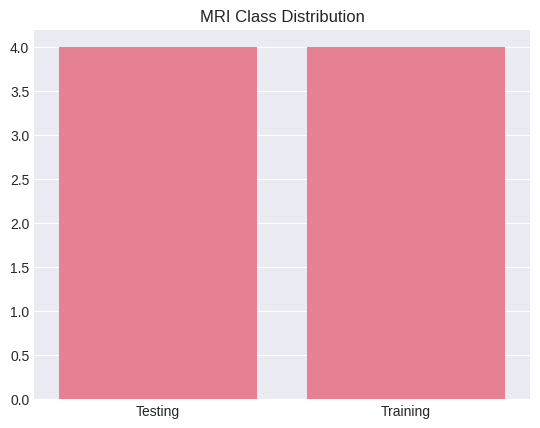

No image files found in /content/preprocessed/brain-tumor/Training
No image files found in /content/preprocessed/brain-tumor/Testing


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os, random
from PIL import Image
import seaborn as sns
import cv2 # Import cv2

mri_root = "/content/preprocessed/brain-tumor"
wm_root = "/content/preprocessed/logos"

# count classes
# Assuming the subdirectories inside mri_root are the classes
mri_classes = [d for d in os.listdir(mri_root) if os.path.isdir(os.path.join(mri_root, d))]
mri_counts = {c: len(os.listdir(os.path.join(mri_root, c))) for c in mri_classes}
sns.barplot(x=list(mri_counts.keys()), y=list(mri_counts.values()))
plt.title("MRI Class Distribution")
plt.show()

# show random examples
# Sample a number of classes up to the actual number of classes
num_samples = min(4, len(mri_classes))
for cls in random.sample(mri_classes, num_samples):
    class_path = os.path.join(mri_root, cls)
    if os.path.exists(class_path) and os.path.isdir(class_path):
        sample_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if sample_files:
            sample_file = random.choice(sample_files)
            img_path = os.path.join(class_path, sample_file)
            # Use cv2.imread to load the image
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) # Load as grayscale

            if img is not None:
                plt.imshow(img, cmap='gray'); plt.title(cls); plt.show()
            else:
                print(f"Could not load image: {img_path}")
        else:
             print(f"No image files found in {class_path}")

In [ ]:
!pip install torch torchvision tqdm pillow


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import save_image, make_grid
from torch.utils.data import DataLoader
from tqdm import tqdm


In [ ]:
data_dir = "/content/preprocessed/brain-tumor"

transform = transforms.Compose([
    transforms.Resize(64), # Resize to 64x64
    transforms.CenterCrop(64), # Crop to 64x64
    transforms.Grayscale(num_output_channels=1), # Ensure grayscale
    transforms.ToTensor(), # Convert to tensor (scales to [0, 1])
    transforms.Normalize([0.5], [0.5])  # Normalize to [-1, 1] from [0, 1]
])

dataset = datasets.ImageFolder(root=data_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

In [ ]:
nz = 100  # Latent vector size
ngf = 64  # Generator feature map size
ndf = 64  # Discriminator feature map size
nc = 1    # Channels (3 for RGB, 1 if grayscale)

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),

            # Output 1 value per image (flattened)
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        output = self.main(input)
        return output.view(-1)  # flatten to [batch_size]


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

netG = Generator().to(device)
netD = Discriminator().to(device)

criterion = nn.BCELoss()
optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))


In [ ]:
epochs = 50
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

for epoch in range(epochs):
    for i, (data, _) in enumerate(tqdm(dataloader)):
        real = data.to(device)
        b_size = real.size(0)
        label_real = torch.ones(b_size, device=device)
        label_fake = torch.zeros(b_size, device=device)

        # Train Discriminator
        netD.zero_grad()
        output = netD(real).view(-1)
        lossD_real = criterion(output, label_real)
        lossD_real.backward()

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        output = netD(fake.detach()).view(-1)
        lossD_fake = criterion(output, label_fake)
        lossD_fake.backward()
        optimizerD.step()

        # Train Generator
        netG.zero_grad()
        output = netD(fake).view(-1)
        lossG = criterion(output, label_real)
        lossG.backward()
        optimizerG.step()

    print(f"Epoch [{epoch+1}/{epochs}]  Loss_D: {lossD_real+lossD_fake:.4f}  Loss_G: {lossG:.4f}")

    # Save sample images
    with torch.no_grad():
        fake_images = netG(fixed_noise).detach().cpu()
    save_image(fake_images, f"/content/generated_samples_epoch_{epoch+1}.png", normalize=True)


100%|██████████| 55/55 [00:10<00:00,  5.41it/s]


Epoch [1/50]  Loss_D: 2.5645  Loss_G: 0.7183


100%|██████████| 55/55 [00:08<00:00,  6.24it/s]


Epoch [2/50]  Loss_D: 0.2808  Loss_G: 2.5310


100%|██████████| 55/55 [00:09<00:00,  5.78it/s]


...

Epoch [48/50]  Loss_D: 0.1564  Loss_G: 4.0040


100%|██████████| 55/55 [00:09<00:00,  5.95it/s]


Epoch [49/50]  Loss_D: 0.0775  Loss_G: 4.7758


100%|██████████| 55/55 [00:08<00:00,  6.30it/s]


Epoch [50/50]  Loss_D: 0.0574  Loss_G: 4.5376


In [ ]:
torch.save(netG.state_dict(), "dcgan_brain_generator.pth")


In [ ]:
import torch
import torchvision.utils as vutils
import os
import numpy as np

save_dir = "/content/generated_brain_images"
os.makedirs(save_dir, exist_ok=True)

num_images = 20000
batch_size = 64
latent_dim = 100  # same z_dim you used in training

for i in range(0, num_images, batch_size):
    z = torch.randn(batch_size, latent_dim, 1, 1, device=device)
    fake_images = netG(z)
    for j, img in enumerate(fake_images):
        vutils.save_image(img, f"{save_dir}/img_{i+j:05d}.png", normalize=True)


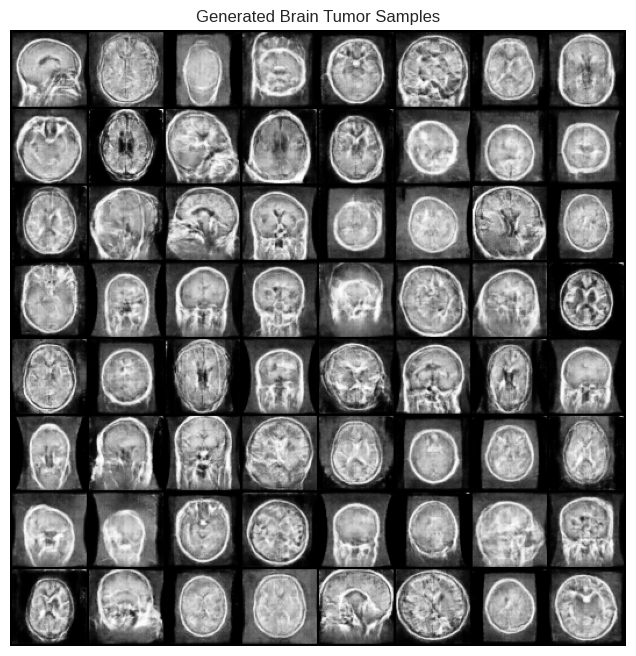

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

z = torch.randn(64, latent_dim, 1, 1, device=device)
fake_images = netG(z).detach().cpu()
grid = vutils.make_grid(fake_images, padding=2, normalize=True)

plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Generated Brain Tumor Samples")
plt.imshow(np.transpose(grid, (1, 2, 0)))
plt.show()
